## Proyecto Final Módulo 5: Estimation of Obesity Levels Based On Eating Habits and Physical Condition

## 1. Introducción

La obesidad representa uno de los problemas de salud pública más urgentes del siglo XXI. Según la Organización Mundial de la Salud, desde 1990 la prevalencia mundial de obesidad se ha más que duplicado, y América Latina no es la excepción: México, Colombia y Perú concentran millones de casos vinculados a estilos de vida sedentarios, hábitos alimenticios deficientes y factores socioeconómicos. La detección temprana y la clasificación precisa del nivel de riesgo de un individuo constituyen pasos esenciales para orientar intervenciones clínicas y políticas de salud preventiva.

En este contexto, el aprendizaje automático supervisado ofrece una oportunidad concreta: a partir de variables fácilmente recolectables —hábitos alimenticios, actividad física, características antropométricas y condiciones de estilo de vida—, es posible construir modelos capaces de clasificar el nivel de obesidad de un individuo con alta precisión y, lo que es igualmente relevante, con criterios *explicables e interpretables* para los tomadores de decisiones.

Según los estándares de la Organización Mundial de la Salud (OMS) y otras normativas internacionales, los rangos de IMC son los siguientes para 18 años o más
:
* Bajo peso (o peso insuficiente): IMC menor a 18.5.
* Peso normal: IMC entre 18.5 y 24.9.
* Sobrepeso: IMC entre 25.0 y 29.9.
* Obesidad Clase I: IMC entre 30.0 y 34.9.
* Obesidad Clase II: IMC entre 35.0 y 39.9.
* Obesidad Clase III: IMC de 40.0 o superior.

Es importante notar que algunos estudios, utilizan etiquetas más granulares para el análisis de datos, subdividiendo el sobrepeso en Sobrepeso Nivel I y Sobrepeso Nivel II. Aunque el IMC es la herramienta estándar, las fuentes subrayan que existen otras mediciones, como el perímetro de la cintura, que ayudan a diagnosticar la obesidad.

El presente proyecto utiliza el conjunto de datos **ObesityDataSet_raw_and_data_sinthetic**, que contiene información de **2,111 individuos** provenientes de México, Perú y Colombia. Incluye la estimación de niveles de obesidad basado en sus hábitos alimenticios y de condición física. La variable respuesta es `NObeyesdad`, que clasifica a cada persona en una de siete categorías de peso: desde *Peso Insuficiente* hasta *Obesidad Tipo III*. El problema se enmarca como una tarea de **clasificación multiclase supervisada** con una variable objetivo de naturaleza ordinal.

Es importante mencionar que el dataset viene balanceado de origen: el 77% de los datos fueron
generados sintéticamente usando la herramienta Weka y el filtro SMOTE, y el 23% restante fue
obtenido directamente de usuarios a través de una plataforma web. Este alto porcentaje de datos
sintéticos puede generar métricas artificialmente optimistas, por lo que los resultados deben
interpretarse como comparativas relativas entre modelos, no como rendimiento absoluto en
producción.

## 1.1. Objetivos del proyecto

1. **Explorar y preprocesar** el conjunto de datos, identificando distribuciones, valores atípicos, relaciones entre variables y requerimientos de transformación.
2. **Entrenar y comparar** una familia representativa de modelos supervisados: modelos lineales con regularización (Lasso / Ridge), ensambles basados en árboles (Random Forest, AdaBoost, XGBoost) y redes neuronales (MLP).
3. **Evaluar e interpretar** los modelos no solo en términos de métricas de rendimiento, sino en cuanto a su explicabilidad: importancia de variables, coeficientes regularizados y comportamiento diferencial entre algoritmos.

## 1.3 Diccionario de Variables

La siguiente tabla describe las variables incluidas en el conjunto de datos. Estas variables se relacionan con características generales de los individuos, hábitos alimenticios, condición física y nivel de obesidad.

| Variable | Nombre completo / significado | Descripción | Tipo de variable |
|------------------|------------------|------------------|------------------|
| `Gender` | Género | Indica el género del individuo. Las respuestas posibles son femenino o masculino. | Categórica nominal |
| `Age` | Edad | Edad del individuo. En el artículo se menciona que las edades de los participantes van aproximadamente de 14 a 61 años. | Numérica |
| `Height` | Estatura | Estatura del individuo medida en metros. | Numérica continua |
| `Weight` | Peso | Peso del individuo medido en kilogramos. | Numérica continua |
| `family_history_with_overweight` | Antecedentes familiares de sobrepeso | Indica si algún familiar del individuo ha sufrido o sufre de sobrepeso. | Categórica nominal |
| `FAVC` | Frequent consumption of high caloric food | Indica si el individuo consume frecuentemente alimentos altos en calorías. | Categórica nominal |
| `FCVC` | Frequency of consumption of vegetables | Mide la frecuencia con la que el individuo consume verduras en sus comidas. | Ordinal / numérica codificada |
| `NCP` | Number of main meals | Representa el número de comidas principales que el individuo realiza diariamente. | Ordinal / numérica codificada |
| `CAEC` | Consumption of food between meals | Indica la frecuencia con la que el individuo consume alimentos entre comidas. | Categórica ordinal |
| `SMOKE` | Consumo de tabaco | Indica si el individuo fuma o no fuma. | Categórica nominal |
| `CH2O` | Daily water consumption | Mide el consumo diario de agua del individuo. | Ordinal / numérica codificada |
| `SCC` | Calories consumption monitoring | Indica si el individuo monitorea o controla las calorías que consume diariamente. | Categórica nominal |
| `FAF` | Physical activity frequency | Mide la frecuencia con la que el individuo realiza actividad física. | Ordinal / numérica codificada |
| `TUE` | Time using technology devices | Representa el tiempo que el individuo utiliza dispositivos tecnológicos como celular, computadora, videojuegos o televisión. | Ordinal / numérica codificada |
| `CALC` | Consumption of alcohol | Indica la frecuencia de consumo de alcohol del individuo. | Categórica ordinal |
| `MTRANS` | Transportation used | Indica el medio de transporte utilizado habitualmente por el individuo. | Categórica nominal |
| `NObeyesdad` | Nivel de obesidad | Variable respuesta. Clasifica al individuo en una de siete categorías: peso insuficiente, peso normal, sobrepeso nivel I, sobrepeso nivel II, obesidad tipo I, obesidad tipo II u obesidad tipo III. | Categórica ordinal / variable respuesta |

| Categoría en la base | Traducción al español | Interpretación |
|------------------------|------------------------|------------------------|
| `Insufficient_Weight` | Peso insuficiente | El individuo se encuentra por debajo del peso considerado normal. |
| `Normal_Weight` | Peso normal | El individuo se encuentra dentro del rango considerado saludable o normal. |
| `Overweight_Level_I` | Sobrepeso nivel I | El individuo presenta un primer nivel de sobrepeso. |
| `Overweight_Level_II` | Sobrepeso nivel II | El individuo presenta un segundo nivel de sobrepeso, más alto que el nivel I. |
| `Obesity_Type_I` | Obesidad tipo I | El individuo presenta obesidad de primer grado. |
| `Obesity_Type_II` | Obesidad tipo II | El individuo presenta obesidad de segundo grado. |
| `Obesity_Type_III` | Obesidad tipo III | El individuo presenta obesidad severa o de tercer grado. |

En este trabajo, `NObesity` será considerada como la variable respuesta, ya que resume la clasificación final del estado nutricional de cada individuo. Debido a que posee siete categorías, el problema puede plantearse como un problema de clasificación multiclase. Además, dado que las categorías siguen un orden natural desde peso insuficiente hasta obesidad tipo III, también puede interpretarse como una variable categórica ordinal.


## 2. Librerías

In [ ]:
#import sys
#!{sys.executable} -m pip install ucimlrepo

# Lectura de datos
#=============================================================
from ucimlrepo import fetch_ucirepo     #Lectura desde el sitio Web
import ssl
import urllib.error
import pandas as pd
import numpy as np


# Visualización
#=============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

import seaborn as sns
import math


# Transformación de datos y Modelado
#=============================================================
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Selección de variables
#=============================================================
from sklearn.feature_selection import SelectFromModel

# Modelos
#=============================================================
from sklearn.linear_model import LogisticRegression, Ridge, HuberRegressor, SGDRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier   # hiperparámetro "estimator" para AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
#from sklearn.feature_selection import RFECV
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Pipeline
#=============================================================
from sklearn.pipeline import Pipeline


# Hiperparámetros
#=============================================================
import scipy.stats as stats   # rangos de hiperparámetros
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV   #Busqueda aleatoria de hiperparámetros
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split


# Métricas
#=============================================================
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
from sklearn.metrics import classification_report


# Tiempo de ejecución
#=============================================================
import time
from tqdm import tqdm

# Sanity check
#=============================================================
from sklearn.base import clone

# Interpretación de resultados
#=============================================================
import shap
from scipy.stats import shapiro

In [2]:
# Semilla para reproducibilidad del código
#===================================================

SEED=42

In [3]:
pd.options.display.float_format = '{:.4f}'.format

## 3. Lectura de datos

In [4]:
try:
    # fetch dataset
    estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)


    # data (as pandas dataframes)
    X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
    y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets
    y.rename(columns={"NObeyesdad": "NObesity"}, inplace=True)

    # metadata
    print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata)

    # variable information
    print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables)


    print("¡Datos descargados correctamente desde la web!")

    datos = pd.concat([X, y], axis=1)

except (ConnectionError, urllib.error.URLError, ssl.SSLCertVerificationError) as e:

    print(f"No se pudo conectar (Error: {e}).")
    print("Cargando el dataset desde el archivo local...")

    #Lectura del archivo local
    datos = pd.read_csv("./datos/ObesityDataSet_raw_and_data_sinthetic.csv")
    datos.rename(columns={"NObeyesdad": "NObesity"}, inplace=True)
    #X = datos.drop(columns= ["NObesity"])
    #y= datos[["NObesity"]]

    print("¡Archivo local cargado con éxito!")


{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

### 3.1 Estructura general del dataset

In [5]:
datos.shape

(2111, 17)

In [6]:
datos.head(4)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObesity
0,Female,21.0000,1.6200,64.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,0.0000,1.0000,no,Public_Transportation,Normal_Weight
1,Female,21.0000,1.5200,56.0000,yes,no,3.0000,3.0000,Sometimes,yes,3.0000,yes,3.0000,0.0000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0000,1.8000,77.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,2.0000,1.0000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0000,1.8000,87.0000,no,no,3.0000,3.0000,Sometimes,no,2.0000,no,2.0000,0.0000,Frequently,Walking,Overweight_Level_I


In [7]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

## 4. Análisis Exploratorio

### 4.1 Valores Faltantes

In [8]:
datos.isnull().sum()

nulos = datos.isnull().sum()
pct_nulos = (nulos / len(datos) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': pct_nulos
})

print('Revisión de valores faltantes')
display(resumen_nulos)

if nulos.sum() == 0:
    print('El dataset no presenta valores faltantes. No se requiere imputación.')


Revisión de valores faltantes


,Valores nulos,Porcentaje (%)
Gender,0,0.0000
Age,0,0.0000
Height,0,0.0000
Weight,0,0.0000
family_history_with_overweight,0,0.0000
FAVC,0,0.0000
FCVC,0,0.0000
NCP,0,0.0000
CAEC,0,0.0000
SMOKE,0,0.0000


El dataset no presenta valores faltantes. No se requiere imputación.


Confirmamos que NO existen valores faltantes

### 4.2 Duplicados

In [9]:
n_dup = datos.duplicated().sum()
print(f'Registros duplicados: {n_dup}')
if n_dup > 0:
    datos = datos.drop_duplicates().reset_index(drop=True)
    print(f'Duplicados eliminados. Nuevo tamaño: {datos.shape}')

Registros duplicados: 24
Duplicados eliminados. Nuevo tamaño: (2087, 17)


### 4.3 Análisis variable target

In [10]:
# Convertir la variable TARGET a tipo categórica
#============================================================================0

# 1. Definimos una lista con el orden exacto que queremos
orden_obesidad = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# 2. Convertimos la columna a un tipo categórico ordenado
datos['NObesity'] = pd.Categorical(
    datos['NObesity'],
    categories=orden_obesidad,
    ordered=True
)


,Frecuencia,Porcentaje (%)
Peso\nInsuficiente,267,12.8000
Peso\nNormal,282,13.5000
Sobrepeso\nNivel I,276,13.2000
Sobrepeso\nNivel II,290,13.9000
Obesidad\nTipo I,351,16.8000
Obesidad\nTipo II,297,14.2000
Obesidad\nTipo III,324,15.5000


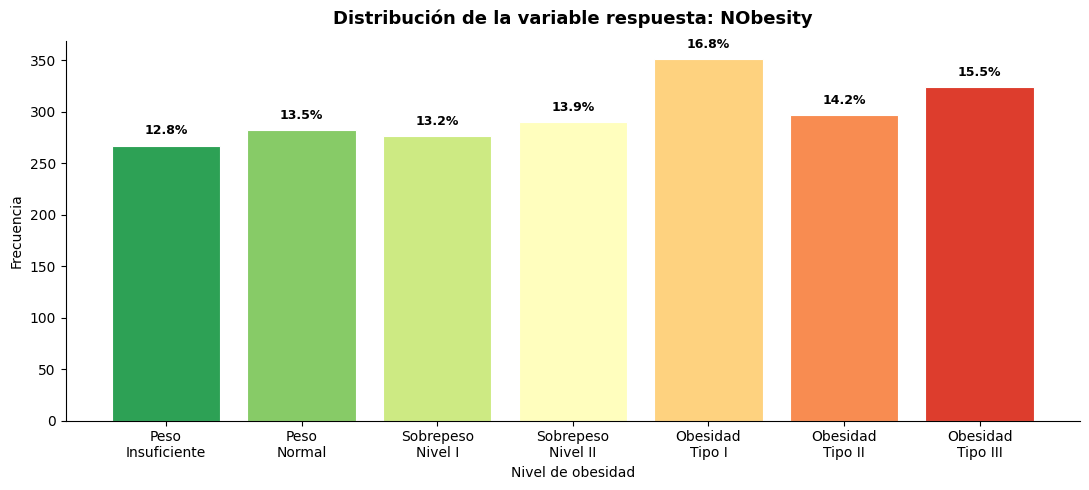


Ratio clase mayoritaria / minoritaria: 1.31
El dataset está razonablemente balanceado.


In [11]:
# Etiquetas amigables para gráficas
etiquetas_obesidad = [
    'Peso\nInsuficiente',
    'Peso\nNormal',
    'Sobrepeso\nNivel I',
    'Sobrepeso\nNivel II',
    'Obesidad\nTipo I',
    'Obesidad\nTipo II',
    'Obesidad\nTipo III']


conteo = (
    datos["NObesity"]
    .value_counts()
    .reindex(orden_obesidad)
)
porcentaje = (conteo / len(datos) * 100).round(1)

tabla_resp = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': porcentaje})
tabla_resp.index = etiquetas_obesidad
display(tabla_resp)

#Gráfica
PALETTE = sns.color_palette('RdYlGn_r', n_colors=7)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(etiquetas_obesidad, conteo.values, color=PALETTE, edgecolor='white', linewidth=0.8)

for bar, pct in zip(bars, porcentaje.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            f'{pct}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Distribución de la variable respuesta: NObesity', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Nivel de obesidad')
ax.set_ylabel('Frecuencia')
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
sns.despine()
plt.tight_layout()
plt.show()

# Balance de clases
max_c = conteo.max()
min_c = conteo.min()
ratio = round(max_c / min_c, 2)
print(f'\nRatio clase mayoritaria / minoritaria: {ratio}')
if ratio > 1.5:
    print('El dataset presenta desbalance moderado. Considerar estrategias de balanceo (class_weight, SMOTE) en la etapa de modelado.')
else:
    print('El dataset está razonablemente balanceado.')

Confirmamos que efectivamente, el dataset está balanceado.

### 4.3.1 Implicaciones del balanceo SMOTE sobre el análisis

El artículo original (Mendoza Palechor & De la Hoz Manotas, 2019) reporta que el dataset fue balanceado con SMOTE *antes* de la distribución que observamos. Esto explica la relativa homogeneidad entre clases y tiene implicaciones directas para nuestro análisis:

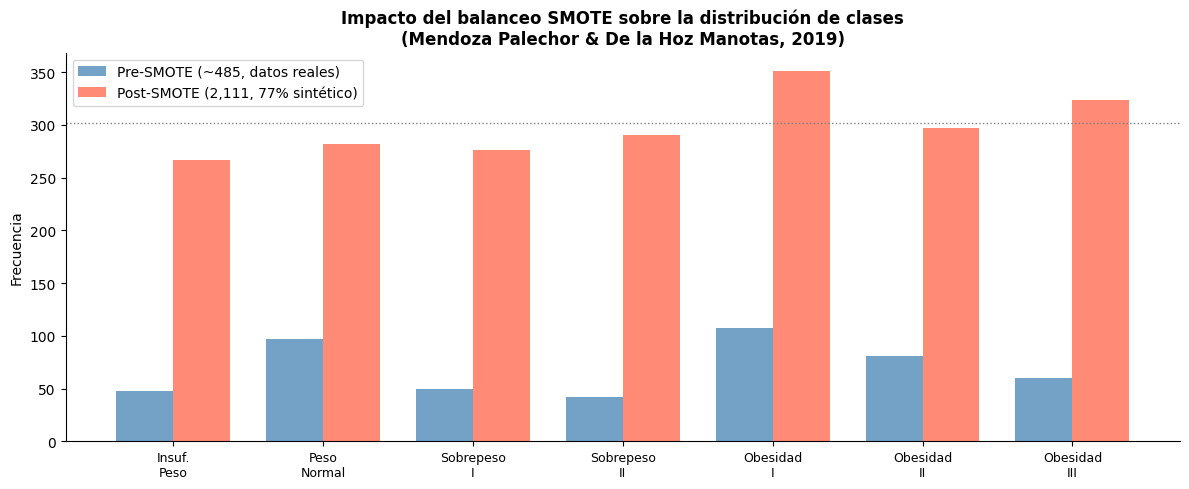

Registros reales (encuesta):     485 (23%)
Registros sintéticos (SMOTE):    1,602 (77%)
Total final:                     2,087
El 77% de los datos es sintético. Las métricas de modelado deben interpretarse con esta limitación.


In [12]:
clases = ['Insuf.\nPeso', 'Peso\nNormal', 'Sobrepeso\nI', 'Sobrepeso\nII',
          'Obesidad\nI', 'Obesidad\nII', 'Obesidad\nIII']

# Distribución original aprox. del paper (485 registros reales)
pre_smote  = [48, 97, 50, 42, 107, 81, 60]   # ~485 total, basado en Fig.1

# Distribución real en nuestro dataset
post_smote = [
    (datos['NObesity'] == cat).sum() for cat in orden_obesidad
]

x = range(len(clases))
w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar([i - w/2 for i in x], pre_smote,  width=w, color='steelblue',  alpha=0.75, label='Pre-SMOTE (~485, datos reales)')
b2 = ax.bar([i + w/2 for i in x], post_smote, width=w, color='tomato',     alpha=0.75, label='Post-SMOTE (2,111, 77% sintético)')
ax.set_xticks(list(x))
ax.set_xticklabels(clases, fontsize=9)
ax.set_ylabel('Frecuencia')
ax.set_title('Impacto del balanceo SMOTE sobre la distribución de clases\n(Mendoza Palechor & De la Hoz Manotas, 2019)',
             fontweight='bold')
ax.legend()
ax.axhline(2111/7, color='gray', linestyle=':', linewidth=1, label='Balance perfecto')
sns.despine()
plt.tight_layout()
plt.show()

total_real     = sum(pre_smote)
total_sintetico = sum(post_smote) - total_real
print(f'Registros reales (encuesta):     {total_real:,} ({total_real/sum(post_smote)*100:.0f}%)')
print(f'Registros sintéticos (SMOTE):    {total_sintetico:,} ({total_sintetico/sum(post_smote)*100:.0f}%)')
print(f'Total final:                     {sum(post_smote):,}')
print('El 77% de los datos es sintético. Las métricas de modelado deben interpretarse con esta limitación.')

### 4.4 Identificar tipos de variables y su estructura

In [13]:
# Separamos variables numéricas y categóricas
#===================================================================


numeric_features = datos.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = datos.select_dtypes(
    include=["object", "str", "bool", "category"]
).columns.tolist()

In [14]:
categorical_features

['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC',
 'MTRANS',
 'NObesity']

In [15]:
for col in categorical_features:
    categorias = datos[col].unique()
    print(f'{col:35s}: {list(categorias)}')

Gender                             : ['Female', 'Male']
family_history_with_overweight     : ['yes', 'no']
FAVC                               : ['no', 'yes']
CAEC                               : ['Sometimes', 'Frequently', 'Always', 'no']
SMOKE                              : ['no', 'yes']
SCC                                : ['no', 'yes']
CALC                               : ['no', 'Sometimes', 'Frequently', 'Always']
MTRANS                             : ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
NObesity                           : ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']


In [16]:
numeric_features

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

In [17]:
datos['FCVC'].unique()

array([2.      , 3.      , 1.      , 2.450218, 2.880161, 2.00876 ,
       2.596579, 2.591439, 2.392665, 1.123939, 2.027574, 2.658112,
       2.88626 , 2.714447, 2.750715, 1.4925  , 2.205439, 2.059138,
       2.310423, 2.823179, 2.052932, 2.596364, 2.767731, 2.815157,
       2.737762, 2.568063, 2.524428, 2.971574, 1.0816  , 1.270448,
       1.344854, 2.959658, 2.725282, 2.844607, 2.44004 , 2.432302,
       2.592247, 2.449267, 2.929889, 2.015258, 1.031149, 1.592183,
       1.21498 , 1.522001, 2.703436, 2.362918, 2.14084 , 2.5596  ,
       2.336044, 1.813234, 2.724285, 2.71897 , 1.133844, 1.757466,
       2.979383, 2.204914, 2.927218, 2.88853 , 2.890535, 2.530066,
       2.241606, 1.003566, 2.652779, 2.897899, 2.483979, 2.945967,
       2.478891, 2.784464, 1.005578, 2.938031, 2.842102, 1.889199,
       2.943749, 2.33998 , 1.950742, 2.277436, 2.371338, 2.984425,
       2.977018, 2.663421, 2.753752, 2.318355, 2.594653, 2.886157,
       2.967853, 2.619835, 1.053534, 2.530233, 2.8813  , 2.824

Los valores decimales observados en las variables ordinales "FCVC", "NCP", "CH2O", "FAF", "TUE" fueron considerados artefactos generados por SMOTE. Debido a que estas variables representan categorías ordinales provenientes de cuestionarios, los valores fueron redondeados al nivel válido más cercano para recuperar su interpretación original.

### 4.5 Etiquetado y corrección de variables numéricas a categóricas

Con el objetivo de obtener una visualización clara renombramos las columnas. Detectamos que algunas variables categóricas contienen números flotantes como respuesta, esto se debe a que se generaron de manera sintética, para preservar la interpretación original redondearemos al entero más cercano.

In [18]:

# Renombramos variables
#================================================================

datos.rename(columns={
    "FAVC"  : "frequently_consump_high_calorie_food",
    "FCVC"  : "freq_consump_vegetables",
    "NCP"   : "num_main_meals",
    "CAEC"  : "consump_food_between_meals",
    "SMOKE" : "smoke",
    "CH2O"  : "consump_water",
    "SCC"   : "monitor_calorie_intake",
    "FAF"   : "freq_physical_activity",
    "TUE"   : "time_using_electronic_devices",
    "CALC"  : "freq_consump_alcohol",
    "MTRANS" : "type_transportation"
}, inplace=True)



# Redondeamos para obtener la interpretación original
#================================================================

datos['freq_consump_vegetables']=round(datos['freq_consump_vegetables'])
datos['num_main_meals'] = round(datos['num_main_meals'])
datos['consump_water'] = round(datos['consump_water'])
datos['freq_physical_activity'] = round(datos['freq_physical_activity'])
datos['time_using_electronic_devices']=round(datos['time_using_electronic_devices'])



# La categoría 4 corresponde a "No answer", lo que en realidad es un NaN
#================================================================

datos['num_main_meals']= datos['num_main_meals'].replace(4, np.nan)



#Convertimos a enteros
#====================================================================================

vars = ['freq_consump_vegetables', 'num_main_meals', 'consump_water', 'freq_physical_activity', 'time_using_electronic_devices']

for variable in vars:
    datos[variable]= datos[variable].astype('Int64')

In [19]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Gender                                2087 non-null   str     
 1   Age                                   2087 non-null   float64 
 2   Height                                2087 non-null   float64 
 3   Weight                                2087 non-null   float64 
 4   family_history_with_overweight        2087 non-null   str     
 5   frequently_consump_high_calorie_food  2087 non-null   str     
 6   freq_consump_vegetables               2087 non-null   Int64   
 7   num_main_meals                        1938 non-null   Int64   
 8   consump_food_between_meals            2087 non-null   str     
 9   smoke                                 2087 non-null   str     
 10  consump_water                         2087 non-null   Int64   
 11  monitor_calorie

Una vez que cambiamos nombres a las columnas y que tenemos el código que correspondería a la respuesta original, hacemos el mapeo para que aparezca la etiqueta de acuerdo al cuestionario original.

In [20]:

# Definición de las etiquetas y mapeo
#====================================================================================
vegetables ={1: "Never", 2: "Sometimes", 3: "Always"}
meals = {1:"Between 1 and 2",2:"Three" , 3: "More than three"}
water = {1: "Less than a liter", 2: "Between 1 and 2 L",3: "More than 2 L"}
activity = {0: "Never", 1:"1 or 2 days", 2: "2 or 4 days", 3:"4 or 5 days"}
devices = {0: "0-2 hours", 1: "3-5 hours", 2: "More than 5 hours"}


datos['freq_consump_vegetables'] = datos['freq_consump_vegetables'].map(vegetables)
datos['num_main_meals'] = datos['num_main_meals'].map(meals)
datos['consump_water']= datos['consump_water'].map(water)
datos['freq_physical_activity'] = datos['freq_physical_activity'].map(activity)
datos['time_using_electronic_devices']=datos['time_using_electronic_devices'].map(devices)


# Convertir a Categórica Ordinal
#====================================================================================

orden_vegetables = ["Never","Sometimes","Always"]
orden_meals = ["Between 1 and 2", "Three" , "More than three"]
orden_water = ["Less than a liter", "Between 1 and 2 L", "More than 2 L"]
orden_activity = ["Never", "1 or 2 days", "2 or 4 days", "4 or 5 days"]
orden_devices = ["0-2 hours", "3-5 hours", "More than 5 hours"]

datos['freq_consump_vegetables'] = pd.Categorical(datos['freq_consump_vegetables'],categories=orden_vegetables,ordered=True)
datos['num_main_meals'] = pd.Categorical(datos['num_main_meals'], categories=orden_meals, ordered=True)
datos['consump_water']= pd.Categorical(datos['consump_water'], categories=orden_water, ordered=True)
datos['freq_physical_activity'] = pd.Categorical(datos['freq_physical_activity'], categories=orden_activity, ordered=True)
datos['time_using_electronic_devices']=pd.Categorical(datos['time_using_electronic_devices'], categories=orden_devices, ordered=True)



In [21]:
numeric_features = datos.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = datos.select_dtypes(
    include=["object", "str", "bool", "category"]
).columns.tolist()

In [22]:
numeric_features

['Age', 'Height', 'Weight']

In [23]:
categorical_features

['Gender',
 'family_history_with_overweight',
 'frequently_consump_high_calorie_food',
 'freq_consump_vegetables',
 'num_main_meals',
 'consump_food_between_meals',
 'smoke',
 'consump_water',
 'monitor_calorie_intake',
 'freq_physical_activity',
 'time_using_electronic_devices',
 'freq_consump_alcohol',
 'type_transportation',
 'NObesity']

### 4.6 Análisis Variables Numéricas

In [24]:
def tabla_descriptiva(df, cols):
    """Genera tabla descriptiva extendida con sesgo y curtosis."""
    desc = df[cols].describe().T
    desc['skewness'] = df[cols].skew()
    desc['kurtosis'] = df[cols].kurtosis()
    desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)
    return desc.round(3)

display(tabla_descriptiva(datos, numeric_features))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,CV (%)
Age,2087.0000,24.3530,6.3690,14.0000,19.9160,22.8480,26.0000,61.0000,1.5140,2.7680,26.2000
Height,2087.0000,1.7030,0.0930,1.4500,1.6300,1.7020,1.7690,1.9800,-0.0250,-0.5560,5.5000
Weight,2087.0000,86.8590,26.1910,39.0000,66.0000,83.1010,108.0160,173.0000,0.2420,-0.7050,30.2000


In [25]:
datos['Age'].quantile(0.99)

np.float64(43.59380528)

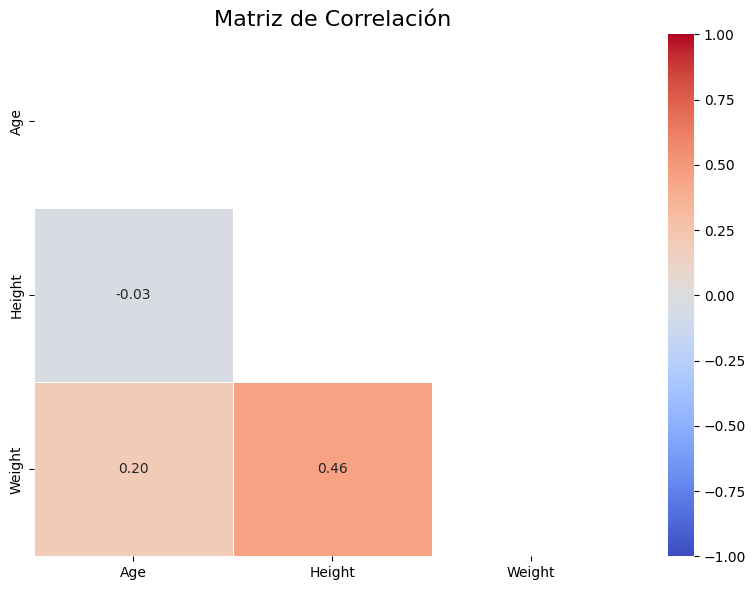

In [26]:
corr_matrix = datos[numeric_features].corr()


# Crear una máscara booleana para el triángulo superior
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    mask=mascara,        # Aplicamos la máscara aquí
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Matriz de Correlación', fontsize=16)
plt.tight_layout()
plt.show()

El peso y la altura presentan correlación lineal positiva moderada.

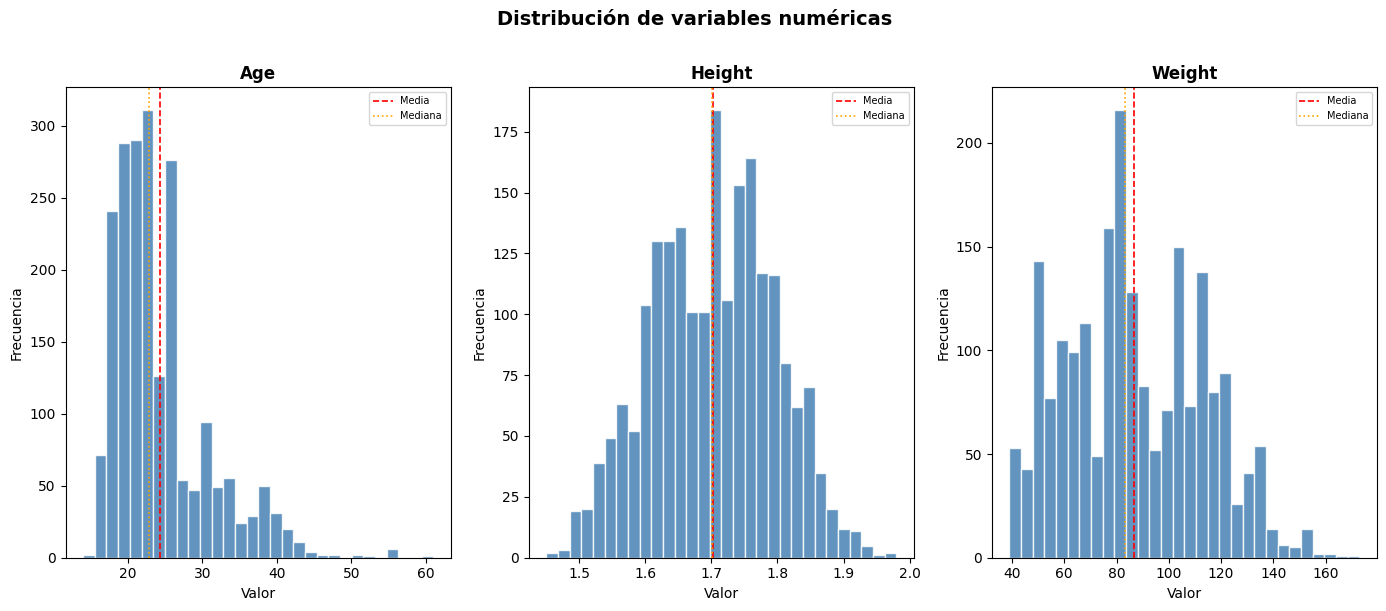

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(datos[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    # Líneas de media y mediana
    axes[i].axvline(datos[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label='Media')
    axes[i].axvline(datos[col].median(), color='orange', linestyle=':',  linewidth=1.2, label='Mediana')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

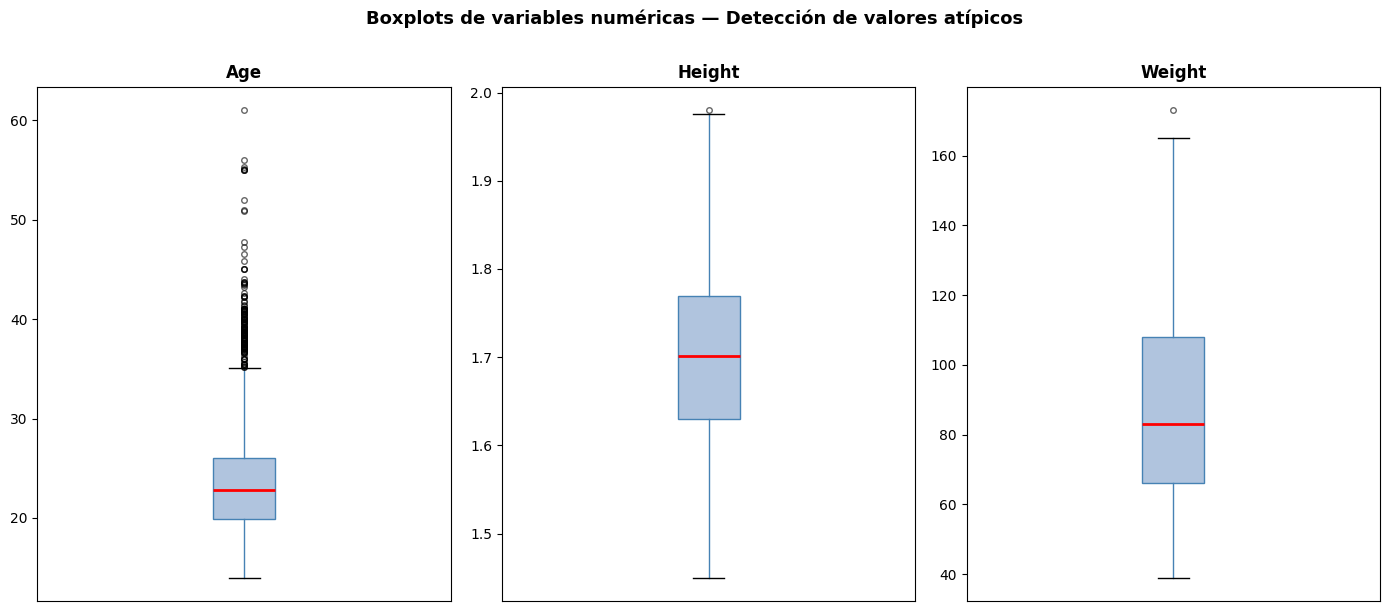

Outliers detectados por regla IQR
  Age     :  167 outliers (8.0%)
  Height  :    1 outliers (0.0%)
  Weight  :    1 outliers (0.0%)


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].boxplot(
        datos[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='steelblue'),
        flierprops=dict(marker='o', color='salmon', markersize=4, alpha=0.6)
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Boxplots de variables numéricas — Detección de valores atípicos',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cuantificación de outliers por IQR
print('Outliers detectados por regla IQR')
for col in numeric_features:
    Q1 = datos[col].quantile(0.25)
    Q3 = datos[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((datos[col] < Q1 - 1.5 * IQR) | (datos[col] > Q3 + 1.5 * IQR)).sum()
    pct_out = round(n_out / len(datos) * 100, 1)
    print(f'  {col:8s}: {n_out:4d} outliers ({pct_out}%)')



**Conclusiones Variables *Numéricas* a nivel total muestra**

+ La **edad (Age)** de los individuos varía entre 14 y 61 años, con una media de 24.35 años y una mediana de 22.85 años, .
+ El **peso (Weight)** oscila entre 39 kgs. y 173 kgs., con un promedio de 87 kgs. y una mediana de 83 kgs.
+ La **estatura (Weight)** presenta valores entre 1.45 m y 1.98 m, tanto la media como la mediana coinciden con un valor de 1.70 mts.
+ El **peso** y la **estatura** presentan una correlación lineal positiva moderada (0.46)

Con respecto a las distribuciones tenemos lo siguiente:

+ La **edad** presenta una distribución asimétrica, sesgada hacia la derecha, con un 1% de la muestra con 44 años o más.
+ La **estatura** muestra una distribución aproximadamente simétrica con forma cercana a una campana, centrada alrededor de 1.70 metros, lo que sugiere una distribución relativamente normal.
+ El **peso** presenta una mayor dispersión y una distribución multimodal, indicando la existencia de distintos grupos de individuos con características corporales diferenciadas, lo cual es consistente con la presencia de múltiples categorías de obesidad en la variable objetivo.


### 4.6b Prueba de normalidad (Shapiro-Wilk)

Los modelos lineales (GLM, Ridge, Lasso) se benefician de distribuciones aproximadamente
normales. Verificamos formalmente la normalidad de las variables continuas principales para
justificar el uso de modelos no paramétricos y la elección de MAE como función de pérdida
más robusta.

In [29]:
np.random.seed(SEED)
VARS_NORM = ['Age', 'Height', 'Weight']
n_sample  = min(2000, len(datos))
sample    = datos[VARS_NORM].sample(n_sample, random_state=SEED)

print(f'Prueba de normalidad Shapiro-Wilk (muestra n={n_sample})')
print(f'{"Variable":10s} {"Shapiro W":>12s} {"p-value":>14s} {"Normal?":>8s}')
print('-' * 50)
for col in VARS_NORM:
    stat, p = shapiro(sample[col])
    print(f'{col:10s} {stat:12.4f} {p:14.4e} {"Sí" if p > 0.05 else "No":>8s}')

print('\nSesgo y curtosis globales:')
for col in VARS_NORM:
    print(f'  {col:10s}: sesgo={datos[col].skew():+.3f}  curtosis={datos[col].kurtosis():+.3f}')

print('\nInterpretación:')
print('  → Ninguna variable sigue distribución normal (todos p < 0.05).')
print('  → Justifica el uso de modelos no paramétricos (árboles, XGBoost, MLP).')
print('  → Justifica MAE como función de pérdida más robusta que MSE ante outliers.')
print('  → Para GLM/Ridge/Lasso: el escalamiento mitiga el efecto, pero no lo elimina.')

Prueba de normalidad Shapiro-Wilk (muestra n=2000)
Variable      Shapiro W        p-value  Normal?
--------------------------------------------------
Age              0.8711     8.8402e-38       No
Height           0.9933     6.6184e-08       No
Weight           0.9760     8.1960e-18       No

Sesgo y curtosis globales:
  Age       : sesgo=+1.514  curtosis=+2.768
  Height    : sesgo=-0.025  curtosis=-0.556
  Weight    : sesgo=+0.242  curtosis=-0.705

Interpretación:
  → Ninguna variable sigue distribución normal (todos p < 0.05).
  → Justifica el uso de modelos no paramétricos (árboles, XGBoost, MLP).
  → Justifica MAE como función de pérdida más robusta que MSE ante outliers.
  → Para GLM/Ridge/Lasso: el escalamiento mitiga el efecto, pero no lo elimina.


### 4.7 Análisis Variables Categóricas

In [30]:
categorical_features

['Gender',
 'family_history_with_overweight',
 'frequently_consump_high_calorie_food',
 'freq_consump_vegetables',
 'num_main_meals',
 'consump_food_between_meals',
 'smoke',
 'consump_water',
 'monitor_calorie_intake',
 'freq_physical_activity',
 'time_using_electronic_devices',
 'freq_consump_alcohol',
 'type_transportation',
 'NObesity']

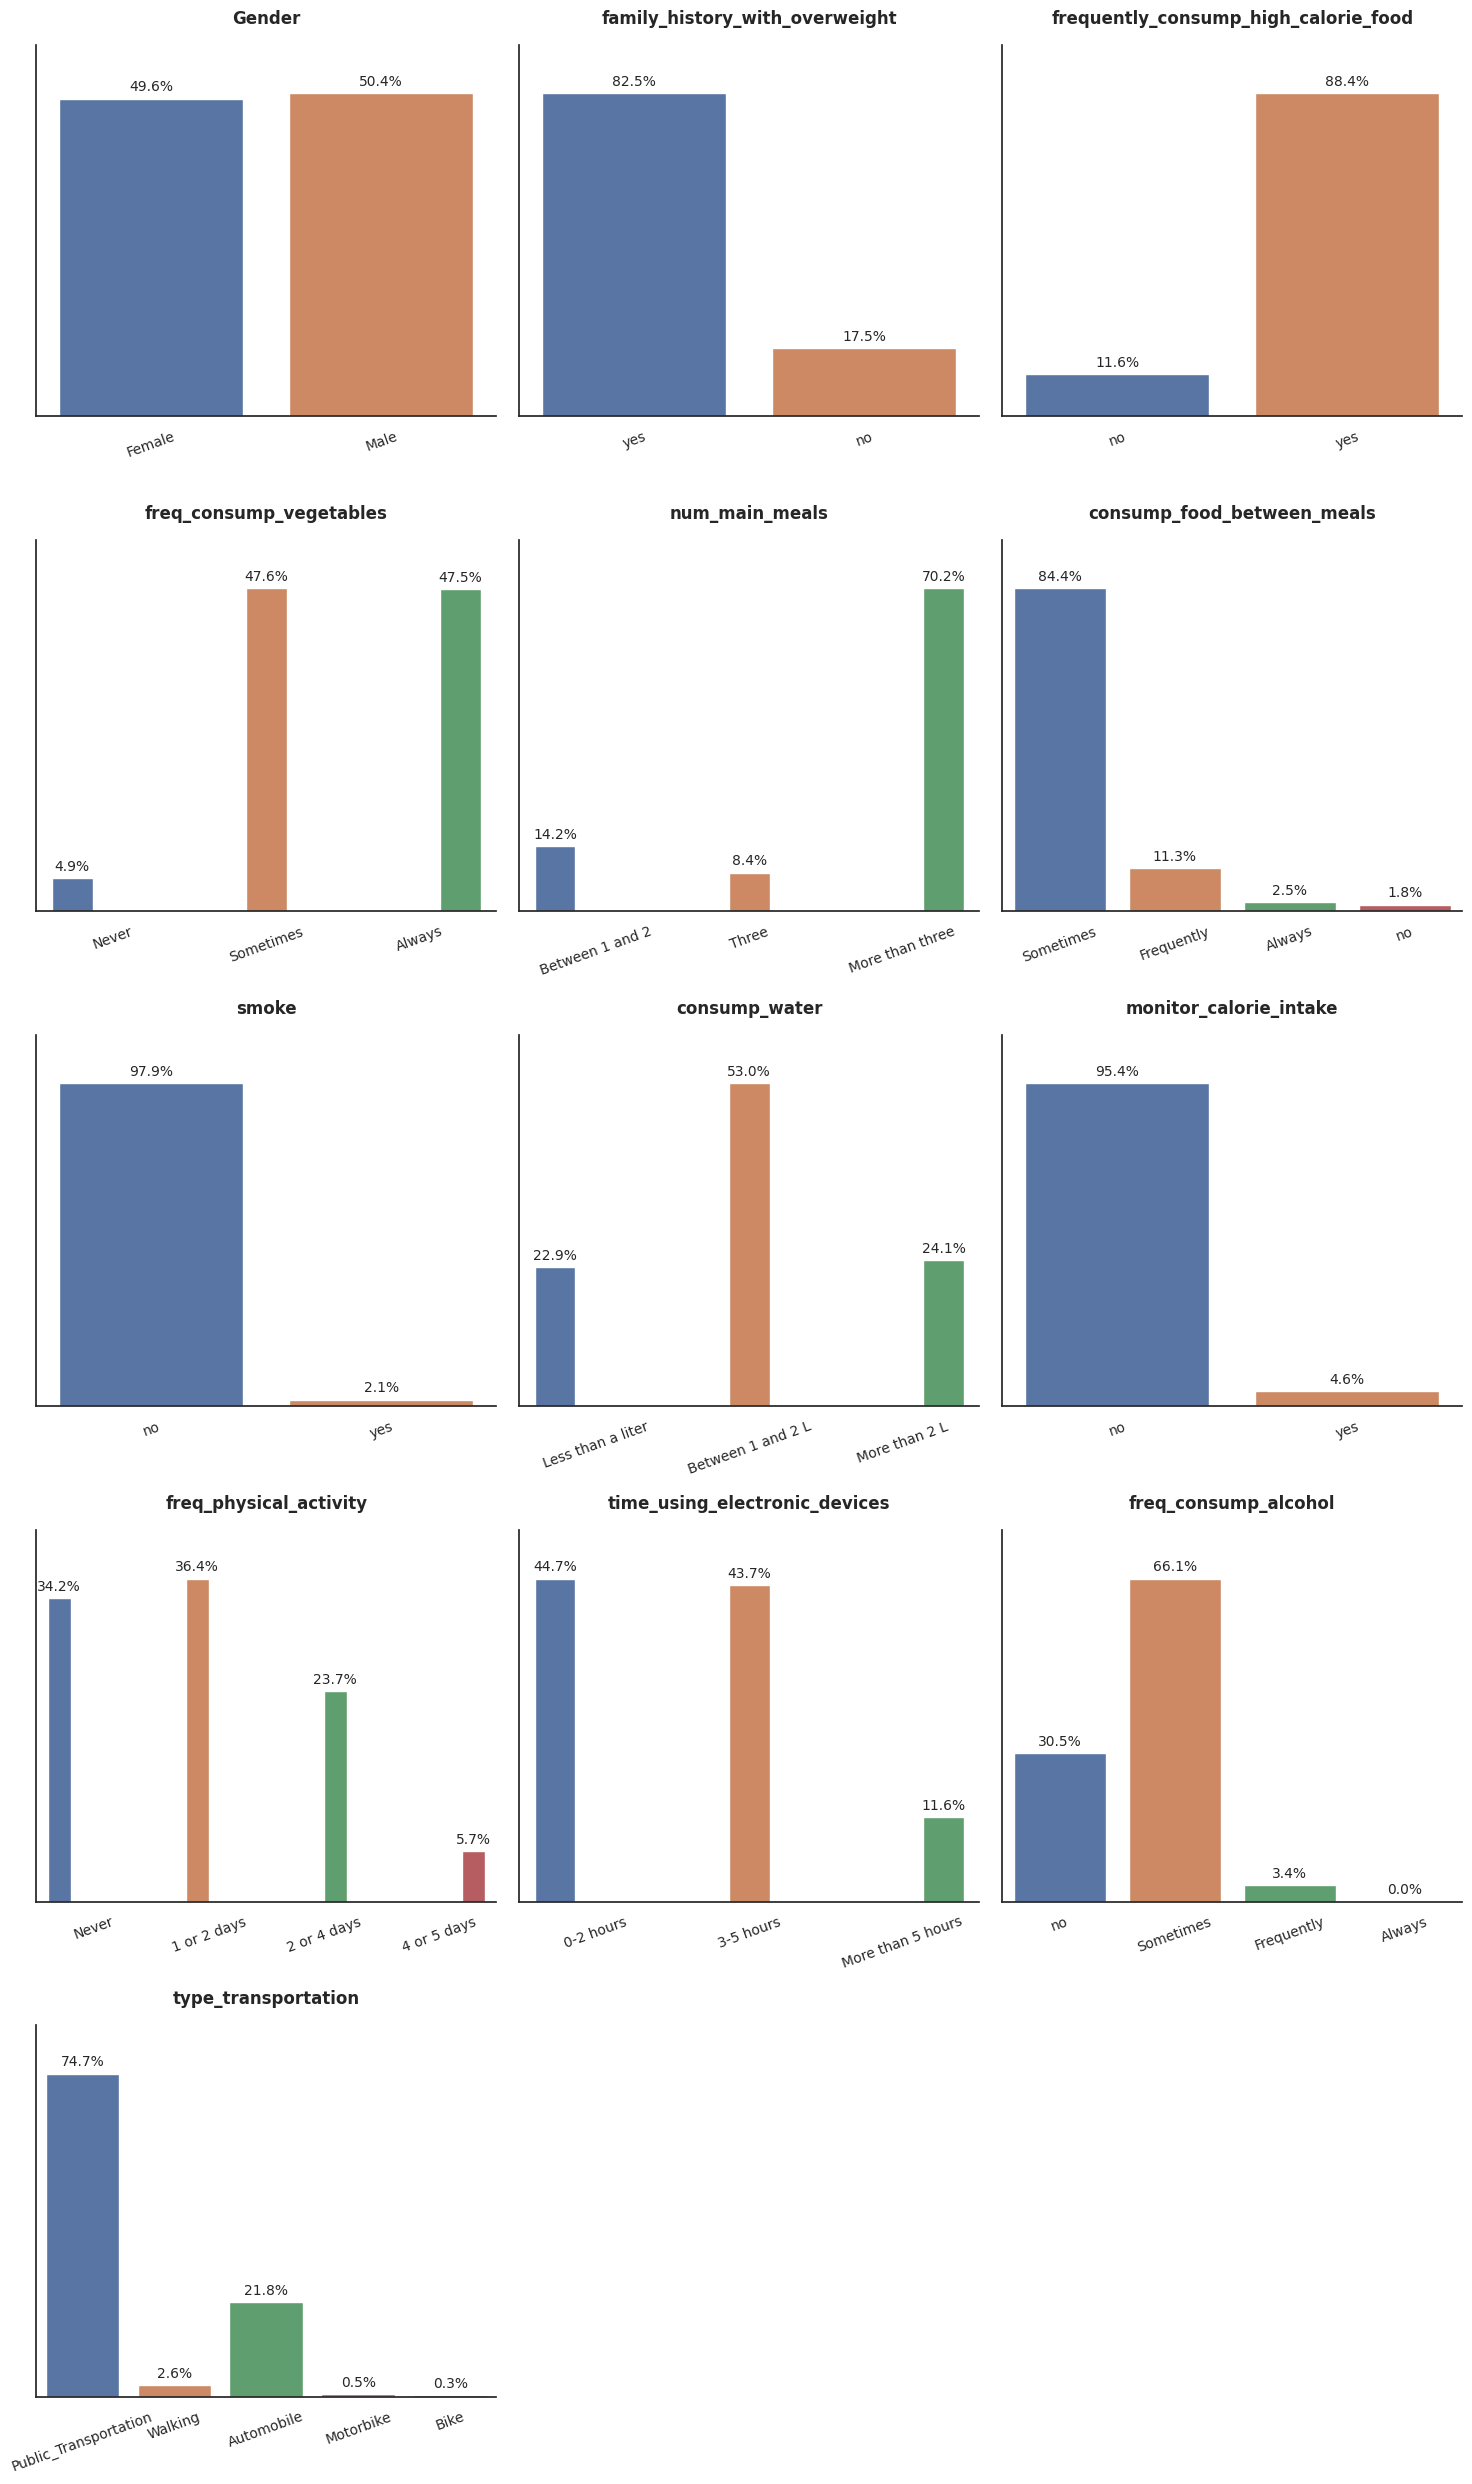

In [31]:
sns.set_theme(style="white")
features_to_plot = [var for var in categorical_features if var != 'NObesity']

# 1. Definimos cuántas columnas queremos en nuestro grid
columnas = 3

# 2. Calculamos las filas necesarias redondeando hacia arriba
filas = math.ceil(len(features_to_plot) / columnas)

# 3. Creamos la figura principal y los "ejes" (los cuadritos del grid)
# Ajustamos el tamaño total: 15 de ancho, y alto proporcional a las filas
fig, axes = plt.subplots(nrows=filas, ncols=columnas, figsize=(15, filas * 5))

# Aplanamos la matriz de ejes a una lista simple de 1 dimensión para iterar fácil
axes = axes.flatten()

# 4. Iteramos sobre las variables y el índice usando enumerate
for i, variable in enumerate(features_to_plot):
    ax_actual = axes[i] # Seleccionamos el cuadro actual

    # MUY IMPORTANTE: Le pasamos ax=ax_actual a Seaborn
    sns.countplot(data=datos, x=variable, hue=variable, stat='percent', ax=ax_actual, legend=False)

    for container in ax_actual.containers:
        # fmt='%.1f%%' formatea con un decimal (45.2%)
        # padding=3 eleva un poco la etiqueta para que no toque la barra
        # size=9 reduce un poco la letra para que quepa bien en el grid
        ax_actual.bar_label(container, fmt='%.1f%%', padding=3, size=10)

    ax_actual.set_title(f"{variable}",fontweight='bold', pad=15)
    ax_actual.tick_params(axis='x', labelsize=10, rotation=20)
    ax_actual.set_xlabel('')
    ax_actual.margins(y=0.15) #'margins' agrega un 15% de espacio extra arriba de la barra más alta
    ax_actual.set_yticks([])
    ax_actual.set_ylabel('')

# 5. Si el número de variables es impar, nos sobrarán cuadros vacíos al final.
# Los ocultamos para que el lienzo se vea limpio:
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Quitamos los bordes superior y derecho de las gráficas para un look más limpio (estilo minimalista)
sns.despine()

plt.tight_layout()
plt.show()

**Conclusiones variables *categóricas* a total muestra**

+ La muestra está equilibrada en cuanto al género, 50% hombres y 50% mujeres
+ 8 de cada 10 dijeron tener antecedentes familiares con sobrepeso
+ 9 de cada 10 afirma consumir frecuentemente comida con alto nivel calórico
+ 8 de cada 10 menciona que algunas veces ingiere alimentos entre comidas

+ El 5% de los individuos menciona que no come vegetales
+ Solo el 2% dice que fuma
+ Casi un 5% monitorea las calorías que consume
+ 53% toma entre 1 y 2 litros de agua al día
+ 7 de cada 10 realiza más de 3 comidas principales al día
+ 3 de cada 10 nunca hace actividad física
+ Casi un 12% menciona que pasa más de 5 hrs. al día usando celulares, tabletas, computadoras, etc.
+ 6 de cada 10 llega a consumir algunas veces alcohol
+ 7 de cada 10 usa transporte público

### 4.8 Relación entre variables numéricas y el nivel de obesidad

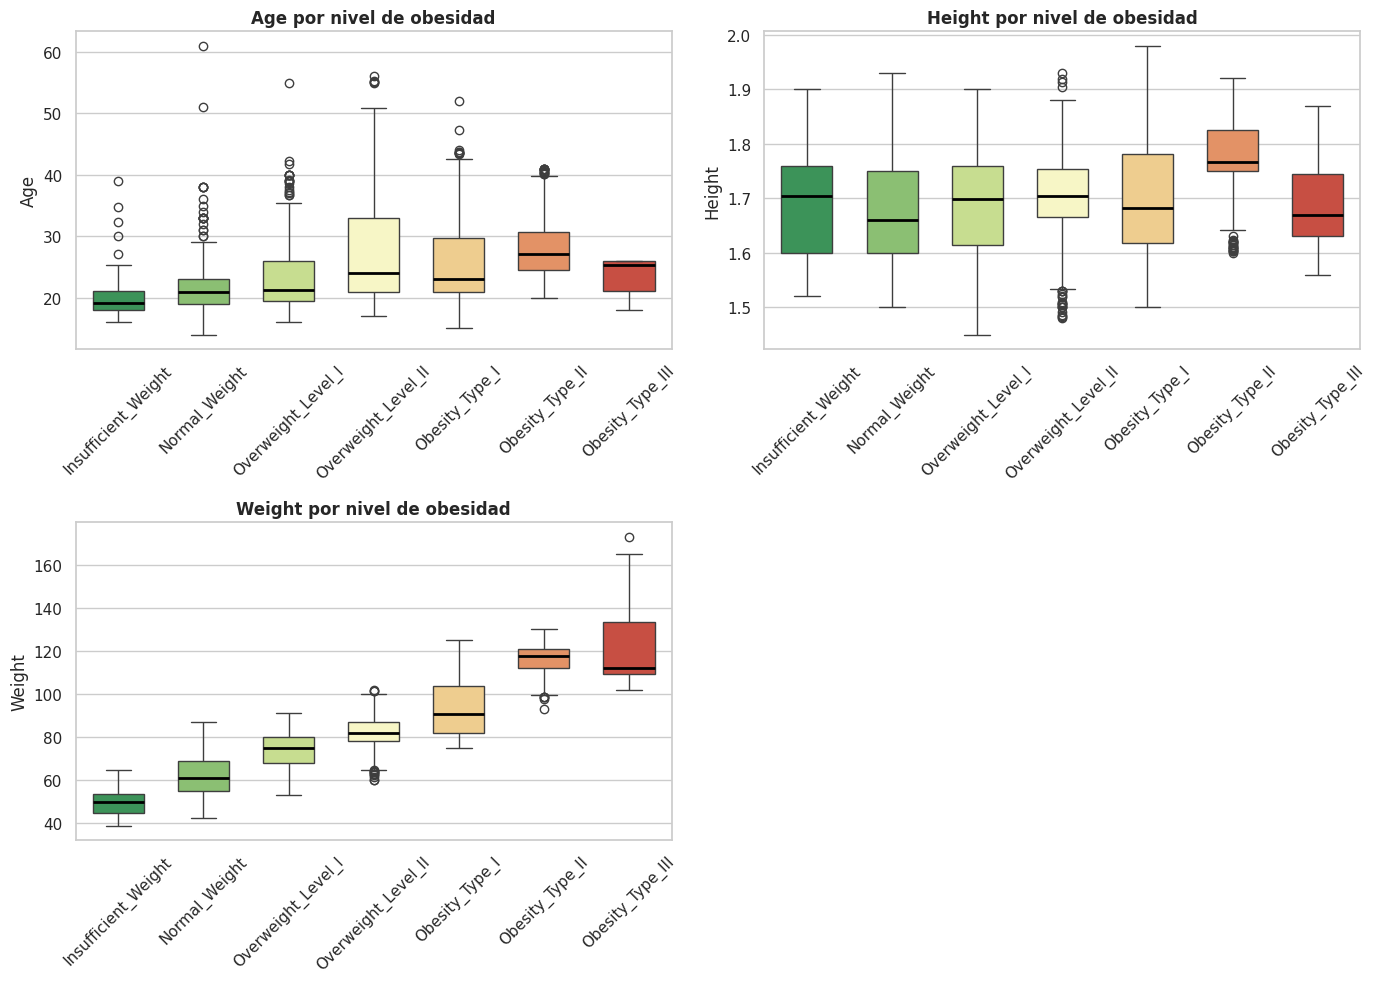

In [32]:
# 1. Configuramos el estilo de fondo
sns.set_theme(style="whitegrid")

# 2. Configuración de la cuadrícula
columnas = 2
filas = math.ceil(len(numeric_features) / columnas)

# Creamos la figura principal y los ejes
fig, axes = plt.subplots(nrows=filas, ncols=columnas, figsize=(14, filas * 5))

# Aplanamos la matriz de ejes a una lista simple
axes = axes.flatten()

# 3. Iteramos sobre las variables numéricas
for i, variable in enumerate(numeric_features):
    ax_actual = axes[i]

    # Creamos el boxplot
    # NOTA: Ya no necesitamos el parámetro 'order' porque la b variable ya es categórica ordinal
    sns.boxplot(
        data=datos,
        x='NObesity',
        y=variable,
        ax=ax_actual,
        hue='NObesity',                               # Colorea cada caja
        palette='RdYlGn_r',                           # Paleta de colores degradado
        width=0.6,                                    # Hace las cajas más anchas
        dodge=False,
        legend=False,                                 # Oculta la leyenda redundante
        #boxprops=dict(alpha=0.9),                     # Aplica el 90% de transparencia
        medianprops=dict(color='black', linewidth=2)  # Remarca la línea de la mediana
    )

    # Personalizamos los títulos y etiquetas
    ax_actual.set_title(f"{variable} por nivel de obesidad", fontweight='bold', fontsize=12)
    ax_actual.set_xlabel('')
    ax_actual.set_ylabel(variable)
    ax_actual.tick_params(axis='x', rotation=45)

# 4. Ocultamos los cuadros sobrantes si el número de variables es impar
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

# Ajustamos el lienzo
plt.tight_layout()
plt.show()

In [33]:
# Quitar el límite de columnas y ampliar el ancho de la pantalla
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

for var in numeric_features:
    print(f"\n--- Descriptivos para la variable: {var} ---")
    descriptivos = datos.groupby('NObesity')[var].describe()
    print(descriptivos)


--- Descriptivos para la variable: Age ---
                       count    mean    std     min     25%     50%     75%     max
NObesity                                                                           
Insufficient_Weight 267.0000 19.7717 2.6881 16.0000 18.0000 19.2116 21.0125 39.0000
Normal_Weight       282.0000 21.7589 5.1219 14.0000 19.0000 21.0000 23.0000 61.0000
Overweight_Level_I  276.0000 23.5403 6.2541 16.0000 19.4994 21.3059 26.0000 55.0000
Overweight_Level_II 290.0000 26.9970 8.0611 17.0000 21.0003 24.0000 33.0000 56.0000
Obesity_Type_I      351.0000 25.8849 7.7557 15.0000 20.8754 22.9755 29.7813 52.0000
Obesity_Type_II     297.0000 28.2338 4.8682 20.0000 24.5822 27.1869 30.7152 41.0000
Obesity_Type_III    324.0000 23.4956 2.7643 18.0000 21.0209 25.3694 26.0000 26.0000

--- Descriptivos para la variable: Height ---
                       count   mean    std    min    25%    50%    75%    max
NObesity                                                                   

**Conclusiones variables numéricas por nivel de obesidad**

+ La gente con nivel de obesidad tipo III (Obesity_Type_III) es muy joven, la edad varía entre los 18 y 26 años.
+ El peso (Weight), como se esperaba, es un claro diferenciador en los niveles de la variable target.

+ Los diagramas de caja muestran que el peso presenta una clara relación con el nivel de obesidad, observándose un incremento progresivo de las medianas conforme aumenta la categoría de obesidad. En contraste, las variables edad y actividad física presentan un mayor solapamiento entre grupos, lo que sugiere una menor capacidad discriminante cuando se analizan individualmente. Aunque existen ligeras diferencias entre categorías, estas no son tan marcadas como las observadas para el peso, por lo que se espera que esta última variable tenga una mayor importancia en los modelos de clasificación.

### 4.9 Variables categóricas vs nivel de obesidad

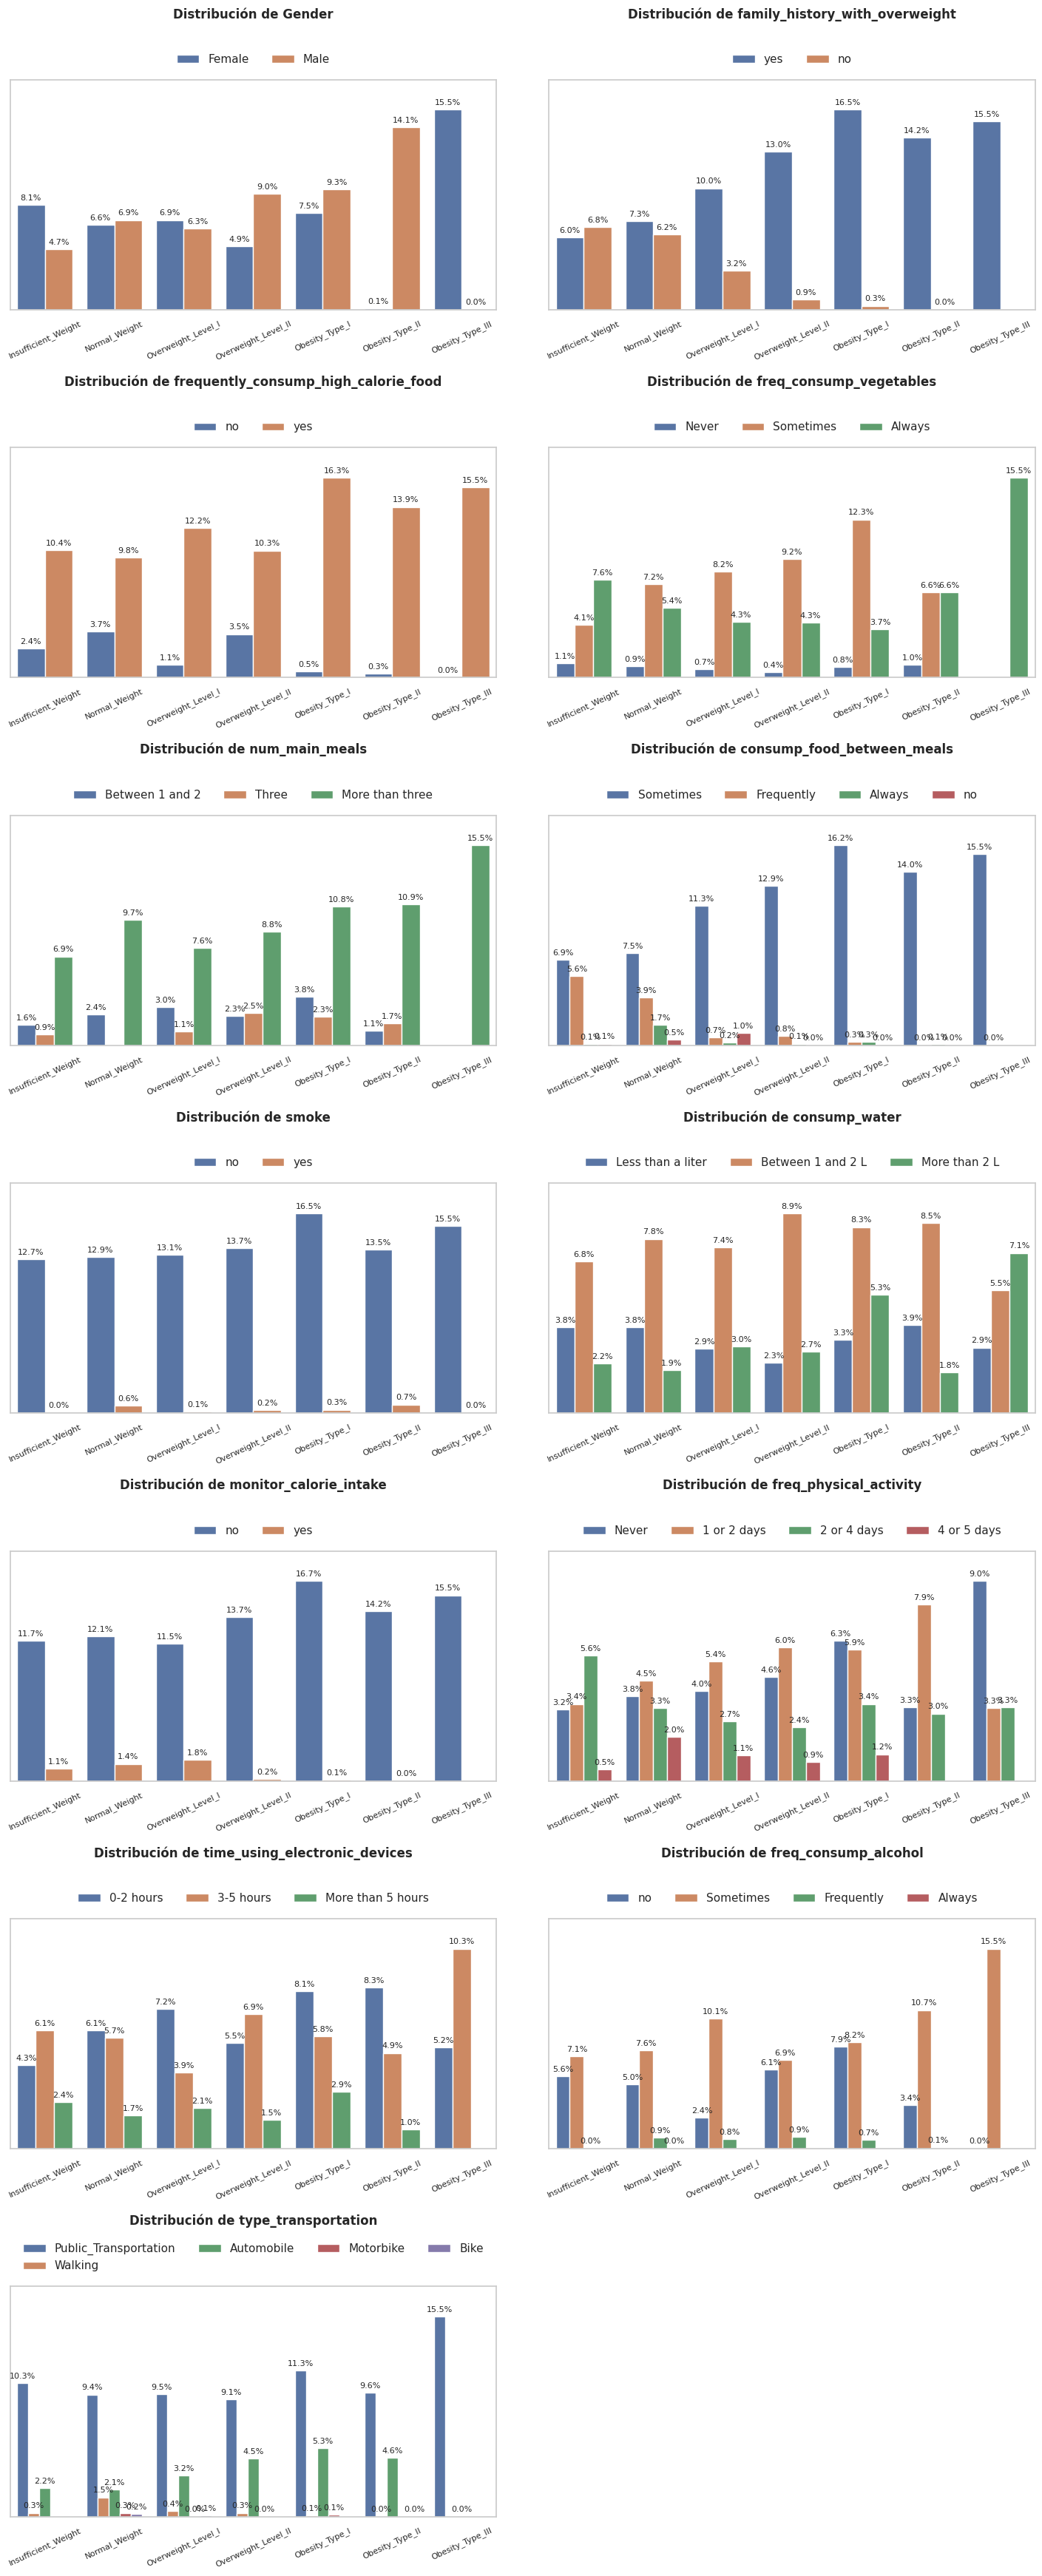

In [34]:
# VARIABLES CATEGÓRICAS POR NIVELES DE VARIABLE TARGET: PROPORCIONES CON RESPECTO AL GRAN TOTAL
#=================================================================================================


sns.set_theme(style="whitegrid")
features_to_plot = [var for var in categorical_features if var != 'NObesity']

# 1. Definimos cuántas columnas queremos en nuestro grid
columnas = 2

# 2. Calculamos las filas necesarias redondeando hacia arriba
filas = math.ceil(len(features_to_plot) / columnas)

# 3. Creamos la figura principal y los "ejes" (los cuadritos del grid)
# Ajustamos el tamaño total: 15 de ancho, y alto proporcional a las filas
fig, axes = plt.subplots(nrows=filas, ncols=columnas, figsize=(15, filas * 5))

# Aplanamos la matriz de ejes a una lista simple de 1 dimensión para iterar fácil
axes = axes.flatten()

# 4. Iteramos sobre las variables y el índice usando enumerate
for i, variable in enumerate(features_to_plot):
    ax_actual = axes[i] # Seleccionamos el cuadro actual

    # MUY IMPORTANTE: Le pasamos ax=ax_actual a Seaborn
    sns.countplot(data=datos, x='NObesity', hue=variable, ax=ax_actual, stat='percent')

    for container in ax_actual.containers:
        # fmt='%.1f%%' formatea con un decimal (45.2%)
        # padding=3 eleva un poco la etiqueta para que no toque la barra
        # size=9 reduce un poco la letra para que quepa bien en el grid
        ax_actual.bar_label(container, fmt='%.1f%%', padding=3, size=8)

    ax_actual.set_title(f"Distribución de {variable}", fontweight='bold', fontsize=12, pad=60)
    ax_actual.set_xlabel('')
    ax_actual.tick_params(axis='x', labelsize=8, rotation=25) # Rotamos textos 45 grados
    ax_actual.set_yticks([])
    ax_actual.set_ylabel('')
    #'margins' agrega un 15% de espacio extra arriba de la barra más alta

    ax_actual.margins(y=0.15)
    # Movemos la leyenda de cada subgráfico
    #sns.move_legend(ax_actual, "upper left", bbox_to_anchor=(1, 1))
    if ax_actual.get_legend(): # Check if a legend exists before trying to move it
        sns.move_legend(
            ax_actual,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=4,
            title=None,
            frameon=False
        )

# 5. Si el número de variables es impar, nos sobrarán cuadros vacíos al final.
# Los ocultamos para que el lienzo se vea limpio:
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

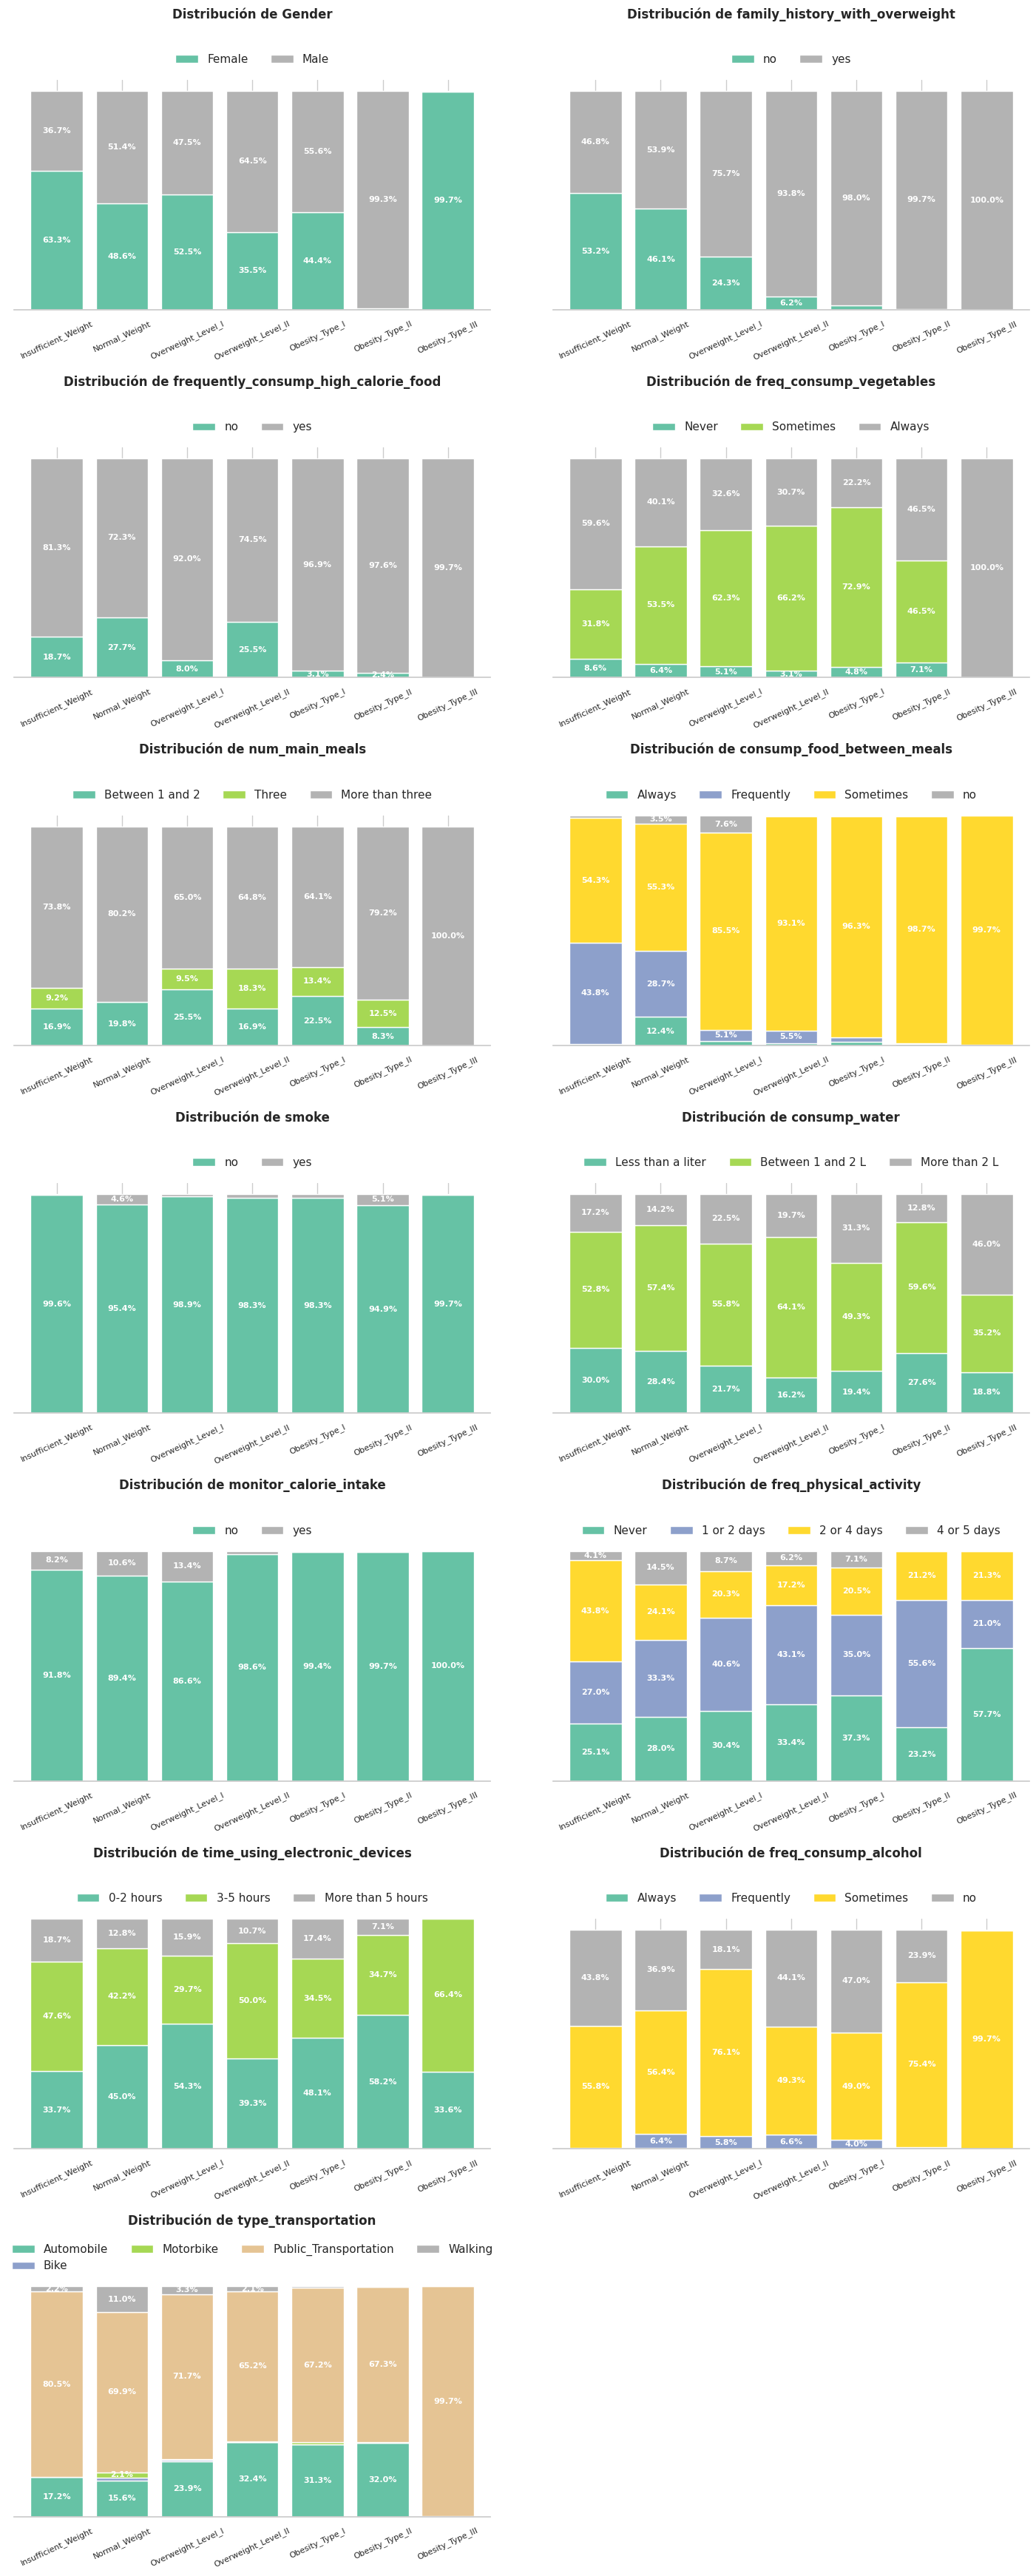

In [35]:
# DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS POR NIVELES DE VARIABLE TARGET: PROPORCIONES CON RESPECTO A CADA NIVEL
#=============================================================================================================



sns.set_theme(style="whitegrid")
features_to_plot = [var for var in categorical_features if var != 'NObesity']

columnas = 2
filas = math.ceil(len(features_to_plot) / columnas)
fig, axes = plt.subplots(nrows=filas, ncols=columnas, figsize=(15, filas * 5))
axes = axes.flatten()

for i, variable in enumerate(features_to_plot):
    ax_actual = axes[i]

    # -------------------------------------------------------------------------
    # 1. CREAMOS UNA TABLA CRUZADA NORMALIZADA POR FILA ('index')
    # Esto asegura que cada nivel de obesidad sume 1 (o 100 al multiplicar)
    tabla_apilada = pd.crosstab(datos['NObesity'], datos[variable], normalize='index') * 100

    # 2. GRAFICAMOS DIRECTAMENTE DESDE PANDAS
    # Le pasamos el ax_actual para que se dibuje en el cuadro correcto del grid
    tabla_apilada.plot(kind='bar', stacked=True, ax=ax_actual, width=0.8, colormap='Set2')
    # -------------------------------------------------------------------------

    # 3. ETIQUETAS CENTRADAS
    for container in ax_actual.containers:
        # Usamos label_type='center' para que el texto quede en medio de cada segmento apilado
        # Ocultamos textos menores al 2% para que no se amontonen visualmente si hay segmentos muy pequeños
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 2 else '' for v in container]
        ax_actual.bar_label(container, labels=labels, label_type='center', size=8, color='white', fontweight='bold')

    ax_actual.set_title(f"Distribución de {variable}", fontweight='bold', fontsize=12, pad=60)
    ax_actual.set_xlabel('')
    ax_actual.tick_params(axis='x', labelsize=8, rotation=25)
    ax_actual.set_yticks([])
    ax_actual.set_ylabel('')
    # En barras apiladas al 100%, ya no necesitamos tanto margen arriba
    ax_actual.margins(y=0.05)

    # Movemos la leyenda
    sns.move_legend(
        ax_actual,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        title=None,
        frameon=False
    )

# 5. Si el número de variables es impar, nos sobrarán cuadros vacíos al final.
# Los ocultamos para que el lienzo se vea limpio:
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Quitamos las líneas de los bordes
sns.despine(left=True, bottom=False)


plt.tight_layout()
plt.show()

**Conclusiones variables categóricas por variable target**

+ 4 de cada 10 es clasificado con algún tipo de obesidad, mismos que mencionan tener antecedentes familiares con sobrepeso.

+ De los que presentan algún tipo de obesidad, declaran consumir con frecuencia alimentos con alto nivel calórico, ingieren alimentos entre las comidas principales y no monitorean las calorías que consumen.

+ El 15.5% de los entrevistados registran obesidad tipo III, todas son mujeres, de las cuales 6 de cada 10 nunca hacen actividad física, hacen más de 3 comidas principales, 46% toma más de 2 litros de agua al día, todas utilizan transporte público y, casi 7 de cada 10 pasa de 3 a 5 horas utilizando celulares, tabletas, computadoras o algún dispositivo electrónico. Además, todas mencionan que algunas veces toman alcohol.

+ Las personas con obesidad tipo III consumen verduras en todas sus comidas en el 100% de los casos. Asimismo, representan el porcentaje más alto en el consumo diario de más de dos litros de agua.

+ El 14% que presenta obesidad tipo II, son del género masculino.

+ De los que se identificaron con peso insuficiente (Insufficient Weight), el 63% son mujeres.


### 4.10 IMC — Uso exclusivamente exploratorio

Calculamos el **Índice de Masa Corporal** (IMC = Peso / Altura²) únicamente para verificar
la coherencia del etiquetado y visualizar la separabilidad de clases. **El IMC NO se
incluirá como feature en ningún modelo**, ya que es una variable derivada directamente de
Weight y Height, lo que inflaría artificialmente las métricas.

In [36]:
datos['IMC'] = (datos['Weight'] / (datos['Height'] ** 2)).round(2)

print('Variable IMC creada. Estadísticas básicas:')
print(datos['IMC'].describe().round(2))

# Umbrales OMS
RANGOS_OMS = {
    'Insufficient_Weight': (0,    18.5),
    'Normal_Weight':        (18.5, 25.0),
    'Overweight_Level_I':   (25.0, 27.5),
    'Overweight_Level_II':  (27.5, 30.0),
    'Obesity_Type_I':       (30.0, 35.0),
    'Obesity_Type_II':      (35.0, 40.0),
    'Obesity_Type_III':     (40.0, 999),
}

print('\n=== Consistencia IMC calculado vs. etiqueta NObesity ===')
print(f'{"Categoría":25s} {"IMC medio":>10s} {"IMC min":>8s} {"IMC max":>8s} {"Rango OMS":>20s}')
print('-' * 80)
for cat in orden_obesidad:
    sub   = datos[datos['NObesity'] == cat]['IMC']
    lo, hi = RANGOS_OMS[cat]
    print(f'{cat:25s} {sub.mean():10.2f} {sub.min():8.2f} {sub.max():8.2f}   [{lo:.1f} – {hi:.1f})')

n_consistente = sum(
    RANGOS_OMS[row['NObesity']][0] <= row['IMC'] < RANGOS_OMS[row['NObesity']][1]
    for _, row in datos.iterrows()
    if row['NObesity'] in RANGOS_OMS
)
print(f'\nRegistros dentro de rango OMS: {n_consistente:,}/{len(datos):,} ({n_consistente/len(datos)*100:.1f}%)')
print('Solapamientos menores se explican por el proceso SMOTE.')

Variable IMC creada. Estadísticas básicas:
count   2087.0000
mean      29.7700
std        8.0200
min       13.0000
25%       24.3700
50%       28.9000
75%       36.1000
max       50.8100
Name: IMC, dtype: float64

=== Consistencia IMC calculado vs. etiqueta NObesity ===
Categoría                  IMC medio  IMC min  IMC max            Rango OMS
--------------------------------------------------------------------------------
Insufficient_Weight            17.39    13.00    19.08   [0.0 – 18.5)
Normal_Weight                  22.01    18.49    24.91   [18.5 – 25.0)
Overweight_Level_I             25.96    22.83    28.77   [25.0 – 27.5)
Overweight_Level_II            28.22    25.71    30.36   [27.5 – 30.0)
Obesity_Type_I                 32.26    29.91    35.17   [30.0 – 35.0)
Obesity_Type_II                36.72    34.05    39.79   [35.0 – 40.0)
Obesity_Type_III               42.27    36.77    50.81   [40.0 – 999.0)

Registros dentro de rango OMS: 1,919/2,087 (92.0%)
Solapamientos menores s

## 5. Modelado

### 5.1 Configuración del PREPROCESADOR

In [37]:
# COVARIABLES
#===================================================================================================0


# 1. Agrupamos las columnas
#==========================================================
columnas_numericas = ['Age', 'Height', 'Weight']
columna_genero = ['Gender']
columnas_sino = ['family_history_with_overweight', 'frequently_consump_high_calorie_food', 'smoke', 'monitor_calorie_intake']
columnas_ordinales = ['freq_consump_vegetables', 'num_main_meals', 'consump_food_between_meals','consump_water','freq_physical_activity','time_using_electronic_devices','freq_consump_alcohol']
columnas_nominales_restantes = ['type_transportation'] # Las que tienen más de 2 categorías sin orden

# 2. Definimos las reglas exactas para el 0 y el 1
#==========================================================
# El índice 0 recibe el valor 0, el índice 1 recibe el valor 1
cat_genero = [['Male', 'Female']] # Male=0, Female=1

# Para las variables si/no, creamos una lista [['no', 'yes']] repetida 4 veces
cat_sino = [['no', 'yes']] * len(columnas_sino)

# Orden de la categorías en variables Ordinales
cat_frecuencia = [["Never","Sometimes","Always"],
                  ["Between 1 and 2", "Three" , "More than three", "No Answer"],
                  ['no', 'Sometimes', 'Frequently', 'Always'],
                  ["Less than a liter", "Between 1 and 2 L", "More than 2 L"],
                  ["Never", "1 or 2 days", "2 or 4 days", "4 or 5 days"],
                  ["0-2 hours", "3-5 hours", "More than 5 hours"],
                  ['no', 'Sometimes', 'Frequently', 'Always']]


# 3. Definimos un mini-pipeline para las variables ordinales (necesitamos imputar los NaN)
#==========================================================
pipeline_ordinal = Pipeline(steps=[
    ('imputador_moda', SimpleImputer(strategy='most_frequent')),
    ('codificador_ordinal', OrdinalEncoder(categories=cat_frecuencia))
])


# 4. Armamos el ColumnTransformer
#==========================================================
preprocesador = ColumnTransformer(
    transformers=[
        ('numerica', StandardScaler(), columnas_numericas),  # media = 0 y desv_std = 1
        ('binaria_genero', OrdinalEncoder(categories=cat_genero), columna_genero),
        ('binaria_sino', OrdinalEncoder(categories=cat_sino), columnas_sino),
        ('ordinal_frec', pipeline_ordinal, columnas_ordinales),
        ('nominal', OneHotEncoder(drop='first', sparse_output=False), columnas_nominales_restantes)
    ],
    remainder='passthrough'
)


# 5. Forzamos a que la salida del "transformer" siga siendo un dataframe
# Esto para posteriormente recuperar los nombres originales de las variables
#==========================================================
preprocesador.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerica', ...), ('binaria_genero', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` 

### 5.2 Configuración variable Target

In [38]:
# TARGET
#===================================================================================================


# 1. Definimos el orden lógico en una lista anidada (requerido por OrdinalEncoder)
orden_obesidad = [[
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]]

# 2. Instanciamos el transformador
encoder_y = OrdinalEncoder(categories=orden_obesidad)


# 3. Transformación de la variable:
#   - y[['NObesity']] -> OrdinalEncoder exige datos en 2 dimensiones (como un DataFrame).
#   - .ravel()          -> Aplanamos el resultado a 1D para que SVM/Regresión Logística no se quejen
#   - .astype(int)      -> Convertimos a enteros para que XGBoost/AdaBoost funcionen perfecto
y_modelo = encoder_y.fit_transform(datos[['NObesity']]).ravel().astype(int)

# Ahora y_modelo es un arreglo de numpy de 1D con valores enteros (0, 1, 2, 3, 4, 5, 6)

###  5.3 Estrategia de entrenamiento: Partición Simple (Train/Test)

In [39]:
# Partición de los datos (80% entrenamiento y 20% prueba)
#===================================================================================================

covariables = [col for col in datos.columns if col not in ["NObesity", "IMC"]]
X = datos[covariables].copy()


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y_modelo,
                                                    test_size=0.20,
                                                    random_state=2026,
                                                    stratify=y_modelo
                                                    )

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')


Train: 1,669 | Test: 418


In [40]:
X_train.head()

,Gender,Age,Height,Weight,family_history_with_overweight,frequently_consump_high_calorie_food,freq_consump_vegetables,num_main_meals,consump_food_between_meals,smoke,consump_water,monitor_calorie_intake,freq_physical_activity,time_using_electronic_devices,freq_consump_alcohol,type_transportation
1989,Female,18.8268,1.7464,133.7470,yes,yes,Always,More than three,Sometimes,no,More than 2 L,no,1 or 2 days,3-5 hours,Sometimes,Public_Transportation
1306,Female,24.3176,1.5868,79.1090,yes,yes,Sometimes,Between 1 and 2,Sometimes,no,Between 1 and 2 L,no,1 or 2 days,0-2 hours,no,Public_Transportation
1714,Male,26.3482,1.8303,117.7570,yes,yes,Sometimes,More than three,Sometimes,no,More than 2 L,no,1 or 2 days,0-2 hours,Sometimes,Public_Transportation
1162,Male,34.9938,1.7525,84.7838,yes,yes,Always,More than three,Sometimes,no,More than 2 L,no,4 or 5 days,3-5 hours,no,Automobile
1091,Male,18.0000,1.7597,86.0805,yes,yes,Always,More than three,Sometimes,no,Between 1 and 2 L,no,1 or 2 days,3-5 hours,Sometimes,Public_Transportation


### 5.4 Búsqueda de hiperparámetros con GridSearch

In [41]:
#En las versiones recientes de scikit-learn, el parámetro "multi_class" fue eliminado de LogisticRegression, ahora detecta
#automáticamente si la variable target tiene más de dos clases.


model_params = {
    'modelo_base_LR':{
        'model': LogisticRegression(solver='lbfgs', max_iter=5000, random_state=SEED),
        'params': {} # Sin parámetros para tunear, evalúa el comportamiento por defecto
        },

    'lr_Ridge_L2': {
        'model' : LogisticRegression(solver='lbfgs', l1_ratio=0, max_iter=5000, random_state=SEED),
        'params' : {
            'clasificador__C' : np.logspace(-2,2,10),
        }
    },
    'lr_Lasso_L1': {
        'model': LogisticRegression(solver='saga', l1_ratio=1, max_iter=5000, random_state=SEED),
        'params': {'clasificador__C': np.logspace(-3, 1, 10)}
    },

    'random-forest' : {
        'model' : RandomForestClassifier(random_state=SEED),
        'params' : {
             "clasificador__n_estimators": np.arange(150,350,30),
             "clasificador__max_depth": np.arange(5,30,5),
         }
    },
    'svc' :{
        'model' :  SVC(random_state=SEED),
        'params' : {
             'clasificador__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
             'clasificador__C': np.logspace(-3,3,7),
             'clasificador__gamma': np.logspace(-2,1,10)
        }
    },
    'Naive_Bayes_Gaussian': {
        'model': GaussianNB(),
        'params': {
            'clasificador__var_smoothing': np.logspace(-12, -1, 15)
        },
        'use_encoded_y': False   # trabaja con etiquetas string directamente
    },
    'AdaBoost' :{
        'model' : AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth=1), random_state=SEED),
        'params' : {
            "clasificador__n_estimators": np.arange(150,350,30), # número de árboles de decisión
            "clasificador__learning_rate":[0.01 ,0.1, 0.5, 1, 10], #tasa de aprendizaje

        }
    },
    'XGBoost' : {
        'model' : XGBClassifier(objective='multi:softprob', random_state=SEED),
        'params' :{
            'clasificador__n_estimators': np.arange(150,350,30), # número de etapas de boosting
            'clasificador__learning_rate': [0.01 ,0.1, 0.5, 1, 10], #tasa de aprendizaje
            "clasificador__max_depth": np.arange(1,10,2)
        }
    },
    'MLP': {
        'model':  MLPClassifier(max_iter=500, early_stopping=True, random_state=SEED),
        'params': {
            'clasificador__hidden_layer_sizes': [(100,), (100, 50), (128, 64, 32)],
            'clasificador__activation':         ['relu', 'tanh'],
            'clasificador__alpha':              [0.0001, 0.001, 0.01],
            'clasificador__learning_rate_init': [0.001, 0.01],
        }
    },
}

# EL CICLO DE BÚSQUEDA Y EVALUACIÓN ---

model_scores = []
#selector = RFECV(SVC(kernel='linear'), cv=5, n_jobs=-1)  #feature_importances_ para extraer las variables
#selector_lr = RFECV(LogisticRegression(l1_ratio=1, solver='saga', C=1.0, max_iter=10000, random_state=42), cv=3, n_jobs=-1)


print("Iniciando GridSearchCV y recopilando métricas...\n")
print("-" * 50)

for nombre_modelo, config in tqdm(model_params.items()):
    print(f"Entrenando y optimizando: {nombre_modelo}...")

    # a) Armamos el Pipeline específico
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        #('seleccion_vars', selector),
        ('clasificador', config['model'])
    ])

    # b) Configuramos GridSearchCV
    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # c) Ejecutamos la búsqueda
    busqueda.fit(X_train, y_train)

    # d) Guardamos todo en la lista de diccionarios
    model_scores.append({
        'model': nombre_modelo,
        'score_train': busqueda.score(X_train, y_train),
        'score_test': busqueda.score(X_test, y_test),
        'best_params': busqueda.best_params_,
        'best_pipeline': busqueda.best_estimator_
    })

    print(f"¡{nombre_modelo} terminado!")
    print("-" * 50)

# --- 6. CREACIÓN DEL DATAFRAME FINAL ---
results = pd.DataFrame(model_scores)

print("\nResultados finales de todos los modelos:")
print(results.to_string(index=False)) # Usamos to_string para que se imprima completo en consola

Iniciando GridSearchCV y recopilando métricas...

--------------------------------------------------


  0%|          | 0/9 [00:00<?, ?it/s]

Entrenando y optimizando: modelo_base_LR...


 11%|█         | 1/9 [00:05<00:42,  5.34s/it]

¡modelo_base_LR terminado!
--------------------------------------------------
Entrenando y optimizando: lr_Ridge_L2...


 22%|██▏       | 2/9 [00:14<00:53,  7.63s/it]

¡lr_Ridge_L2 terminado!
--------------------------------------------------
Entrenando y optimizando: lr_Lasso_L1...


 33%|███▎      | 3/9 [00:50<02:04, 20.71s/it]

¡lr_Lasso_L1 terminado!
--------------------------------------------------
Entrenando y optimizando: random-forest...


 44%|████▍     | 4/9 [01:42<02:45, 33.06s/it]

¡random-forest terminado!
--------------------------------------------------
Entrenando y optimizando: svc...


 56%|█████▌    | 5/9 [03:16<03:39, 54.80s/it]

¡svc terminado!
--------------------------------------------------
Entrenando y optimizando: Naive_Bayes_Gaussian...


 67%|██████▋   | 6/9 [03:17<01:50, 36.75s/it]

¡Naive_Bayes_Gaussian terminado!
--------------------------------------------------
Entrenando y optimizando: AdaBoost...


 78%|███████▊  | 7/9 [04:08<01:22, 41.31s/it]

¡AdaBoost terminado!
--------------------------------------------------
Entrenando y optimizando: XGBoost...


 89%|████████▉ | 8/9 [07:25<01:30, 90.72s/it]

¡XGBoost terminado!
--------------------------------------------------
Entrenando y optimizando: MLP...


100%|██████████| 9/9 [07:53<00:00, 52.60s/it]

¡MLP terminado!
--------------------------------------------------

Resultados finales de todos los modelos:


               model  score_train  score_test                                                                                                                                                    best_params                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## 6. Resultados

In [42]:
results

,model,score_train,score_test,best_params,best_pipeline
0,modelo_base_LR,0.8981,0.9043,{},"(ColumnTransformer(remainder='passthrough',\n ..."
1,lr_Ridge_L2,0.9814,0.9713,{'clasificador__C': 100.0},"(ColumnTransformer(remainder='passthrough',\n ..."
2,lr_Lasso_L1,0.9850,0.9713,{'clasificador__C': 10.0},"(ColumnTransformer(remainder='passthrough',\n ..."
3,random-forest,1.0000,0.9569,"{'clasificador__max_depth': 25, 'clasificador_...","(ColumnTransformer(remainder='passthrough',\n ..."
4,svc,1.0000,0.9713,"{'clasificador__C': 1000.0, 'clasificador__gam...","(ColumnTransformer(remainder='passthrough',\n ..."
5,Naive_Bayes_Gaussian,0.6405,0.6268,{'clasificador__var_smoothing': 0.1},"(ColumnTransformer(remainder='passthrough',\n ..."
6,AdaBoost,0.4943,0.4928,"{'clasificador__learning_rate': 0.1, 'clasific...","(ColumnTransformer(remainder='passthrough',\n ..."
7,XGBoost,1.0000,0.9809,"{'clasificador__learning_rate': 0.1, 'clasific...","(ColumnTransformer(remainder='passthrough',\n ..."
8,MLP,0.9838,0.9569,"{'clasificador__activation': 'relu', 'clasific...","(ColumnTransformer(remainder='passthrough',\n ..."


In [43]:
#model_scores

### 6.1 Elección del modelo

A continuación se revisan diferentes métricas para todos los modelos que se entrenaron, a partir de esto elegiremos el "mejor".

=== COMPARATIVA FINAL — TODOS LOS MODELOS (ordenados por F1 Macro) ===


/home/ara/Documents/diplomado_Introduccion_Analitica_a_la_Ciencia_de_Datos/Modulo_5_Aprendizaje_Supervisado/proyecto_final_mod5/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Modelo,Familia,Accuracy Train,Accuracy Test,F1 Macro,Precision Macro,Recall Macro
0,XGBoost,Ensamble,1.0000,0.9809,0.9794,0.9804,0.9792
1,svc,Kernel,1.0000,0.9713,0.9696,0.9701,0.9696
2,lr_Ridge_L2,Lineal,0.9814,0.9713,0.9694,0.9697,0.9693
3,lr_Lasso_L1,Lineal,0.9850,0.9713,0.9693,0.9701,0.9692
4,MLP,Red Neuronal,0.9838,0.9569,0.9547,0.9560,0.9544
5,random-forest,Otro,1.0000,0.9569,0.9539,0.9540,0.9545
6,modelo_base_LR,Lineal,0.8981,0.9043,0.8989,0.9049,0.9009
7,Naive_Bayes_Gaussian,Otro,0.6405,0.6268,0.5933,0.6272,0.6159
8,AdaBoost,Ensamble,0.4943,0.4928,0.4119,0.4766,0.4950


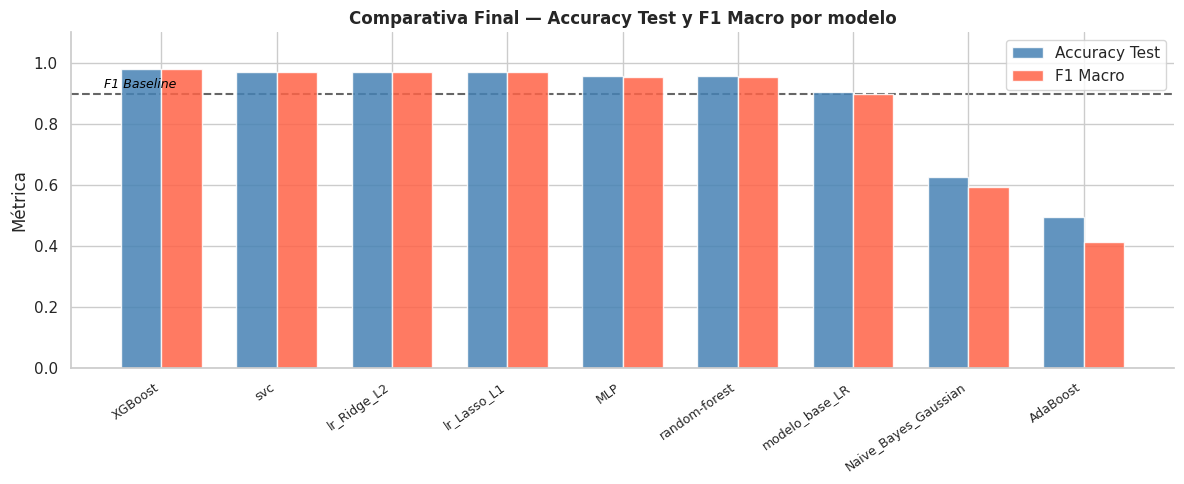

In [44]:
# Unificamos resultados

todos_resultados = []

familia_map = {
    'modelo_base_LR':'Lineal',
    'lr_Ridge_L2': 'Lineal', 'lr_Lasso_L1': 'Lineal',
    'random_forest': 'Ensamble', 'svc': 'Kernel',
    'Naive_Bayes': 'Probabilístico', 'AdaBoost': 'Ensamble',
    'XGBoost': 'Ensamble', 'MLP': 'Red Neuronal'
}

for item in model_scores:
    ypred_i = item['best_pipeline'].predict(X_test)
    todos_resultados.append({
        'Modelo':         item['model'],
        'Familia':        familia_map.get(item['model'], 'Otro'),
        'Accuracy Train': round(item['score_train'], 4),
        'Accuracy Test':  round(item['score_test'],  4),
        'F1 Macro':       round(f1_score(y_test, ypred_i, average='macro'), 4),
        'Precision Macro':round(precision_score(y_test, ypred_i, average='macro'), 4),
        'Recall Macro':   round(recall_score(y_test, ypred_i, average='macro'), 4),
    })

df_comparativa = (pd.DataFrame(todos_resultados)
                    .sort_values('F1 Macro', ascending=False)
                    .reset_index(drop=True))

print("=== COMPARATIVA FINAL — TODOS LOS MODELOS (ordenados por F1 Macro) ===")
display(df_comparativa)

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_comparativa))
width = 0.35

bars1 = ax.bar(x - width/2, df_comparativa['Accuracy Test'], width,
               label='Accuracy Test', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, df_comparativa['F1 Macro'], width,
               label='F1 Macro',      color='tomato',    alpha=0.85)

# 2. Resaltar el rendimiento del modelo base con una línea de referencia
baseline_row = df_comparativa[df_comparativa['Modelo'] == 'modelo_base_LR']
if not baseline_row.empty:
    baseline_f1 = baseline_row['F1 Macro'].values[0]
    ax.axhline(y=baseline_f1, color='black', linestyle='--', alpha=0.6, zorder=0)
    ax.text(-0.5, baseline_f1 + 0.02, 'F1 Baseline', color='black', fontsize=9, fontstyle='italic')



ax.set_xticks(x)
ax.set_xticklabels(df_comparativa['Modelo'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1.1)
ax.set_title('Comparativa Final — Accuracy Test y F1 Macro por modelo', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

El mejor modelo es **XGBoost**, tanto el accuracy como F1 Macro son las más altas en comparación con el resto de los modelos. A continuación obtendremos el reporte de clasificación, matriz de confusión y la importancia de variables.

In [45]:

# MEJOR PIPELINE
#============================================================================
# Seleccionamos el pipeline del modelo que queramos analizar
resultados_best_model = next(item for item in model_scores if item["model"] == "XGBoost")
mejor_pipeline = resultados_best_model['best_pipeline']

# Obtenemos todos los nombres de las columnas generadas por el preprocesador
# (Incluye las variables numéricas y todas las columnas creadas por OneHotEncoder)
nombres_todas_variables = mejor_pipeline.named_steps['preprocesamiento'].get_feature_names_out()


In [46]:
# 1. Entrenar con todo el conjunto de entrenamiento
#==========================================================
mejor_pipeline.fit(X_train, y_train)

#2. Hacer las predicciones directamente sobre datos de prueba
#==========================================================
y_pred = mejor_pipeline.predict(X_test)

# 3. Imprimes las métricas
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")# 1. Entrenar con todo el conjunto de entrenamiento
print(f"F1-score      : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred, average='macro'):.4f}")
print("*"*100)

etiquetas_obesidad = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred,
                                                             target_names=etiquetas_obesidad,
                                                            digits=3))

Accuracy Score: 0.9809
F1-score      : 0.9794
Precision     : 0.9804
Recall        : 0.9792
****************************************************************************************************

Reporte de Clasificación:
                      precision    recall  f1-score   support

Insufficient_Weight      0.962     0.962     0.962        53
      Normal_Weight      0.965     0.965     0.965        57
 Overweight_Level_I      1.000     0.927     0.962        55
Overweight_Level_II      0.935     1.000     0.967        58
     Obesity_Type_I      1.000     1.000     1.000        70
    Obesity_Type_II      1.000     1.000     1.000        60
   Obesity_Type_III      1.000     1.000     1.000        65

           accuracy                          0.981       418
          macro avg      0.980     0.979     0.979       418
       weighted avg      0.981     0.981     0.981       418



<Axes: >

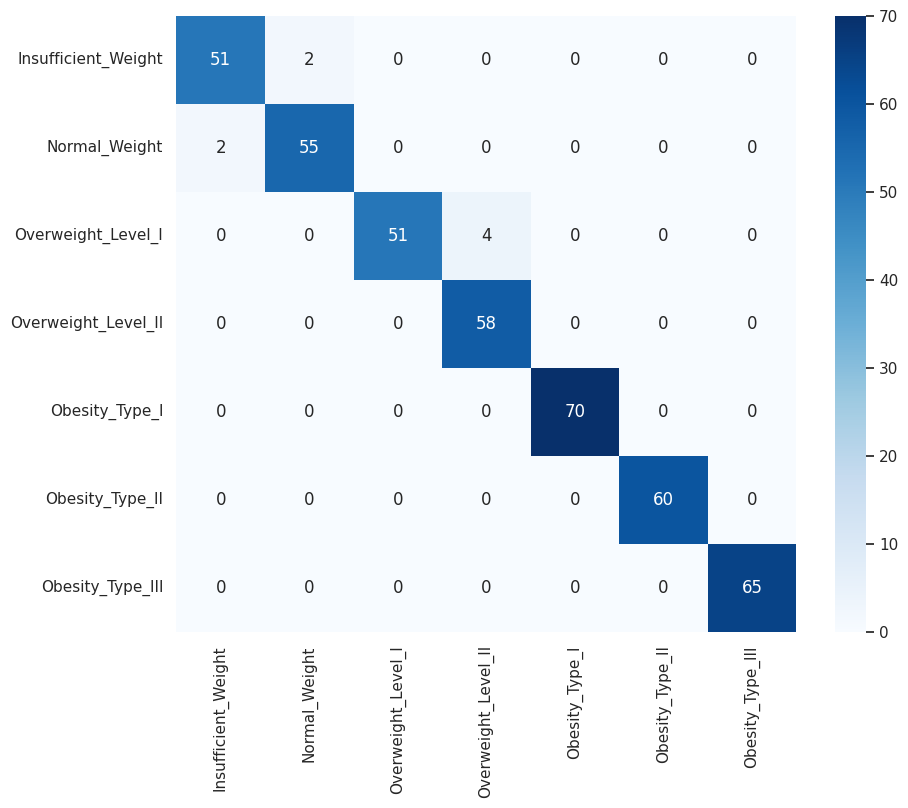

In [47]:
cf_matrix = confusion_matrix(y_test, y_pred)
#sns.heatmap((cf_matrix / np.sum(cf_matrix)*100), annot = True, fmt=".2f", cmap="Blues")
plt.figure(figsize=(10, 8))
sns.heatmap(cf_matrix,
            annot = True,
            fmt=".0f",
            cmap="Blues",
            xticklabels=etiquetas_obesidad, # <-- Nombres del eje X (Predicciones)
            yticklabels=etiquetas_obesidad  # <-- Nombres del eje Y (Valores Reales)
            )

En la matriz de confusión se observa que en las primeras categorías es donde el modelo no logró predecir correctamente.

### 6.2 Sanity check

Como queremos ser un tanto "conservadores", una vez que se eligió el mejor modelo, haremos 100 simulaciones obteniendo al azar conjuntos de entrenamiento y test (sin semilla) y se calcularán diversas métricas para evaluar el rendimiento del modelo, y eso es lo que finalmente se reportará.

Iniciando Sanity Check...


100%|██████████| 100/100 [06:51<00:00,  4.11s/it]



¡Sanity Check completado!

=== REPORTE FINAL (100 Iteraciones) ===
Accuracy        : 0.9683 ± 0.0084
F1 Macro        : 0.9668 ± 0.0088
Precision Macro : 0.9672 ± 0.0088
Recall Macro    : 0.9673 ± 0.0088


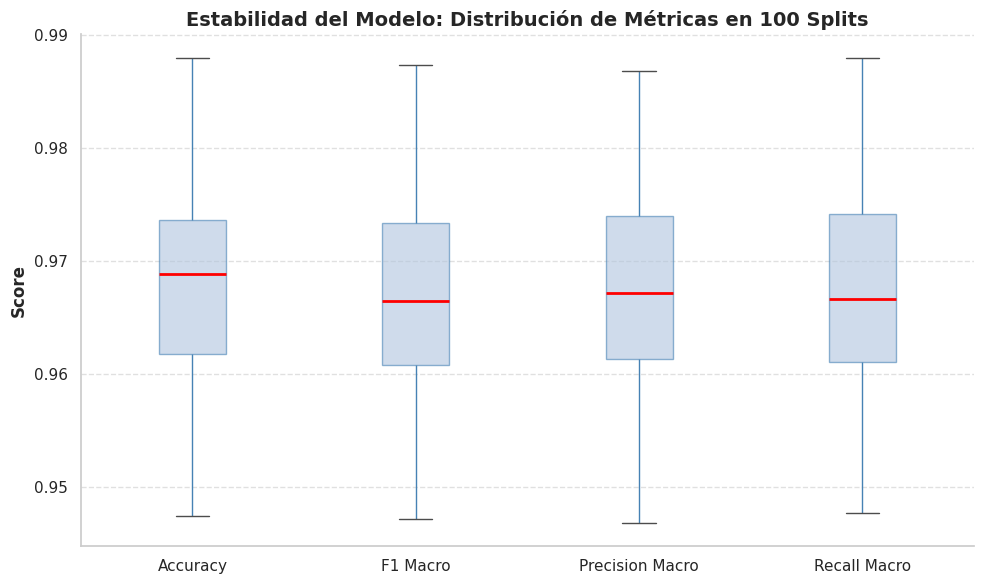

In [48]:

# 1. Diccionario para múltiples métricas
historial_metricas = {
    'Accuracy': [],
    'F1 Macro': [],
    'Precision Macro': [],
    'Recall Macro': []
}


print("Iniciando Sanity Check...")

# Usamos tqdm para ver la barra de progreso
for i in tqdm(range(0, 100)):
    # División de los datos CRUDOS
    X_train, X_test, y_train, y_test = train_test_split(X, y_modelo, test_size=0.2)

    # CLONAR el pipeline ganador para empezar "en limpio"
    pipeline_iteracion = clone(mejor_pipeline)

    # Entrenar TODO el proceso
    pipeline_iteracion.fit(X_train, y_train)

    # Predecir y evaluar en el 20% oculto
    y_pred = pipeline_iteracion.predict(X_test)
    
    # 2. Guardamos todas las métricas de esta iteración
    historial_metricas['Accuracy'].append(accuracy_score(y_test, y_pred))
    historial_metricas['F1 Macro'].append(f1_score(y_test, y_pred, average='macro'))
    historial_metricas['Precision Macro'].append(precision_score(y_test, y_pred, average='macro'))
    historial_metricas['Recall Macro'].append(recall_score(y_test, y_pred, average='macro'))
    
print("\n¡Sanity Check completado!\n")

# 3. Convertimos el diccionario a un DataFrame para facilitar los cálculos
df_scores = pd.DataFrame(historial_metricas)

# 4. Cálculo de Media y Desviación Estándar para el reporte
print("=== REPORTE FINAL (100 Iteraciones) ===")
for columna in df_scores.columns:
    media = df_scores[columna].mean()
    std = df_scores[columna].std()
    # Formateamos para que se vea alineado y profesional
    print(f"{columna:<16}: {media:.4f} ± {std:.4f}")

# 5. Visualización
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_scores,
            patch_artist=True,
            width=0.3,
            boxprops=dict(facecolor='lightsteelblue', edgecolor='steelblue', alpha=0.6),
            medianprops=dict(color='red', linewidth=2),            
            whiskerprops=dict(color='steelblue')
            )

plt.title('Estabilidad del Modelo: Distribución de Métricas en 100 Splits', fontweight='bold', fontsize=14)
plt.ylabel('Score', fontweight='bold')

# Toques estéticos para un reporte limpio
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 6.3 Conclusiones sobre métricas de desempeño

Dado que el conjunto de datos trata sobre un problema de salud pública, el **accuracy** puede quedarse "corto" y llegar a ser engañoso. Por lo anterior se decidió utilizar otras métricas.

*Accuracy*

El dataset de niveles de obesidad es un problema multiclase (con 7 categorías distintas, desde "Peso Insuficiente" hasta "Obesidad Tipo III"). **El accuracy (0.9683 solo nos dice el porcentaje global de aciertos**, tanto positivos como negativos. Si el modelo es excelente clasificando "Peso Normal" (que podría ser una clase mayoritaria) pero es pésimo detectando "Obesidad Tipo III", el accuracy global podría seguir pareciendo alto, ocultando una falla clínica grave.

*Recall Macro*

En el contexto médico, el Recall (Sensibilidad) es la métrica más importante. **Mide la capacidad del modelo para encontrar todos los casos positivos reales de una condición**. En salud, omitir un diagnóstico (Falso Negativo) suele tener un costo humano mayor que un Falso Positivo. El Recall Macro promedia la sensibilidad de las 7 clases por igual, sin importar cuántos registros tenga cada una. Destacamos esta métrica para demostrar que el modelo no está ignorando las categorías de riesgo extremo (como la Obesidad Tipo III) solo porque tengan menos representación en los datos. El Recall (Sensibilidad) para este conjunto de datos fue de 0.9673.

*Precision Macro*

**Precision mide la proporción de todos los casos que el modelo etiquetó como positivos (en este caso de una condición) cuántos realmente la tenían**.
Para que un sistema de estimación sea útil en un consultorio o aplicación de salud, el diagnóstico debe ser confiable para evitar tratamientos o alarmas innecesarias (Falsos Positivos). El Precision Macro nos asegura que cuando el modelo predice un nivel de peso específico, tiene una alta probabilidad de acertar, manteniendo un estándar riguroso a través de todas las categorías. Después de los 100 splits, se obtuvo que la precisión es de 0.9672.

*F1-Score Macro*

**F1-Score es la media armónica entre Precision y Recall, al ser *Macro*, evalúa el modelo dándole el mismo peso a cada clase**. Mientras que el accuracy nos da el rendimiento global validado en 100 particiones, el F1-Score Macro es nuestro principal indicador de equidad del modelo (0.9668). Un F1 Macro alto confirma que nuestro algoritmo aprendió a distinguir los patrones de hábitos alimenticios y condición física para todos los niveles de obesidad de manera equilibrada, sin sesgarse hacia las clases más frecuentes.


### 6.4 Importancia Global de Variables

--- IMPORTANCIA DE VARIABLES (GRADIENT BOOSTING) ---
Total de variables analizadas por el modelo: 19

Top 15 Características Más Importantes:
                                             Variable  Importancia_Porcentaje
0                              binaria_genero__Gender                 37.1660
1                                    numerica__Weight                 13.2505
2                nominal__type_transportation_Walking                 10.6978
3   binaria_sino__frequently_consump_high_calorie_...                  6.3148
4                  ordinal_frec__freq_consump_alcohol                  4.1950
5                                    numerica__Height                  4.0047
6            ordinal_frec__consump_food_between_meals                  3.3344
7                         ordinal_frec__consump_water                  3.1377
8   nominal__type_transportation_Public_Transporta...                  2.4397
9                binaria_sino__monitor_calorie_intake                  2.3464


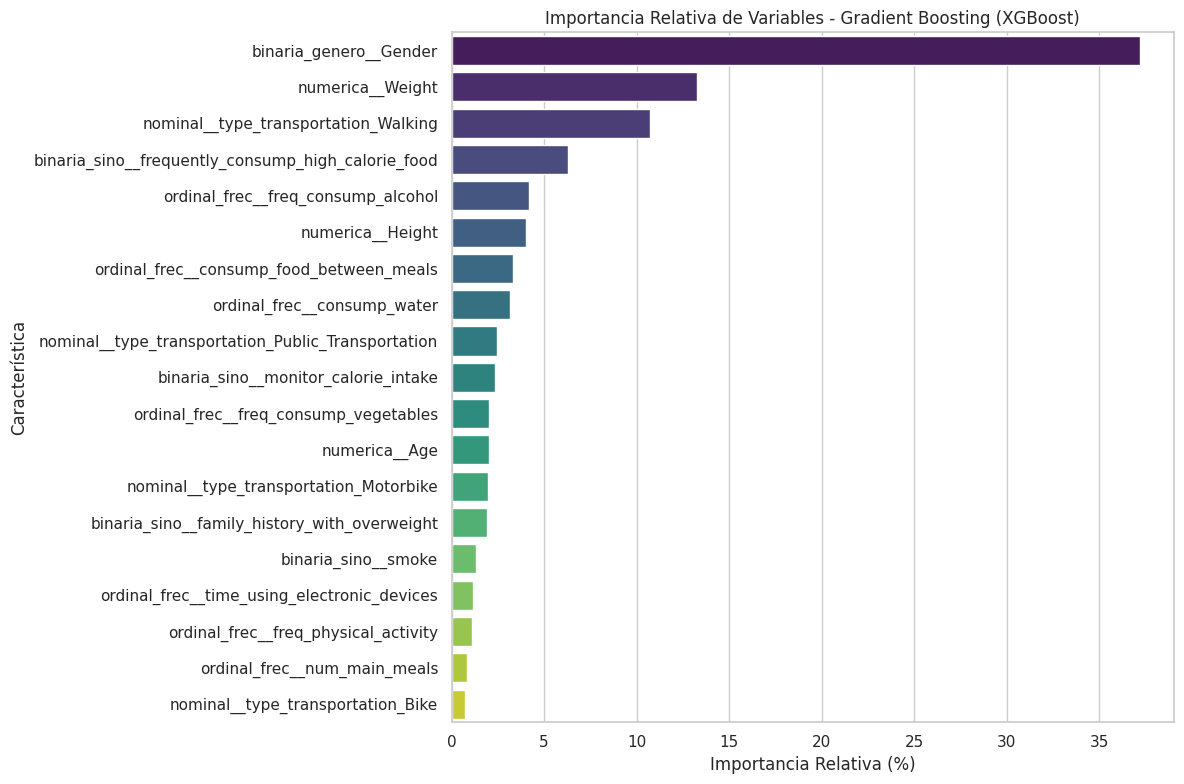

In [49]:
# Extraer el modelo final (Gradient Boosting) y sus importancias
modelo_final = mejor_pipeline.named_steps['clasificador']

# Los modelos de árboles usan 'feature_importances_' en lugar de 'coef_'
importancias_xgb = modelo_final.feature_importances_

# Crear el DataFrame consolidado
df_importancias_xgb = pd.DataFrame({
    'Variable': nombres_todas_variables,
    'Importancia_Gini': importancias_xgb
})

# Ordenar de mayor a menor y resetear el índice
df_importancias_xgb = df_importancias_xgb.sort_values(by='Importancia_Gini', ascending=False).reset_index(drop=True)

# Opcional: Convertir a porcentaje para mejor legibilidad (suman 1.0 por defecto)
df_importancias_xgb['Importancia_Porcentaje'] = df_importancias_xgb['Importancia_Gini'] * 100

# --- IMPRESIÓN DE RESULTADOS ---
print("--- IMPORTANCIA DE VARIABLES (GRADIENT BOOSTING) ---")
print(f"Total de variables analizadas por el modelo: {len(nombres_todas_variables)}")
print("\nTop 15 Características Más Importantes:")
print(df_importancias_xgb[['Variable', 'Importancia_Porcentaje']].head(15))

# --- VISUALIZACIÓN GRÁFICA ---
plt.figure(figsize=(12, 8))

# Usamos barplot con la sintaxis actualizada
sns.barplot(
    data=df_importancias_xgb,
    x='Importancia_Porcentaje',
    y='Variable',
    hue='Variable',
    palette='viridis',
    legend=False
)

plt.title('Importancia Relativa de Variables - Gradient Boosting (XGBoost)')
plt.xlabel('Importancia Relativa (%)')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

Como podemos observar, a nivel global el Género y el peso son las variables más importantes. Sin embargo, al ser un problema de clasificación multi-clase tenemos que ir más allá y revisar por categoría el comportamiento de cada una de las variables explicativas.


### 6.5 Interpretación de Resultados por categorías de la variable target

Nos apoyaremos en la biblioteca "SHAP" para interpretar los resultados

In [50]:
modelo_final

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [51]:
# Transformar los datos manualmente
# SHAP necesita los datos exactamente como los ve el modelo (después del preprocesamiento y la selección)

# Aplicamos el preprocesador a los datos de prueba (X_test)
# Nota: Usamos transform(), NO fit_transform()
X_test_preprocesado = mejor_pipeline.named_steps['preprocesamiento'].transform(X_test)

# Opcional pero recomendado: Convertir la matriz de numpy de vuelta a un DataFrame de Pandas
# para que SHAP lea los nombres de las columnas automáticamente.

X_test_final_df = pd.DataFrame(X_test_preprocesado, columns=nombres_todas_variables)

In [52]:
X_test_final_df

,numerica__Age,numerica__Height,numerica__Weight,binaria_genero__Gender,binaria_sino__family_history_with_overweight,binaria_sino__frequently_consump_high_calorie_food,binaria_sino__smoke,binaria_sino__monitor_calorie_intake,ordinal_frec__freq_consump_vegetables,ordinal_frec__num_main_meals,ordinal_frec__consump_food_between_meals,ordinal_frec__consump_water,ordinal_frec__freq_physical_activity,ordinal_frec__time_using_electronic_devices,ordinal_frec__freq_consump_alcohol,nominal__type_transportation_Bike,nominal__type_transportation_Motorbike,nominal__type_transportation_Public_Transportation,nominal__type_transportation_Walking
1869,-0.2251,0.2459,1.7629,1.0000,1.0000,1.0000,0.0000,0.0000,2.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000
1342,-1.0000,-0.5595,-0.0702,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,2.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
1004,1.5472,-0.5300,-0.3664,1.0000,1.0000,1.0000,0.0000,0.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1023,-0.7350,0.0237,-0.3032,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,1.0000,1.0000,2.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000
2017,0.1625,-0.2314,0.6895,1.0000,1.0000,1.0000,0.0000,0.0000,2.0000,2.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,2.2878,-1.8046,-0.3505,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,2.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
354,2.4233,-1.5130,-0.2570,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2086,-0.1186,0.3936,1.7832,1.0000,1.0000,1.0000,0.0000,0.0000,2.0000,2.0000,1.0000,2.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000
1750,0.1556,1.4357,1.2072,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,2.0000,1.0000,2.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000


In [53]:
# 1. Inicializar el Explainer de SHAP
# Como usamos XGBoost (un modelo de árboles), usamos TreeExplainer para mayor velocidad y exactitud
explainer = shap.TreeExplainer(modelo_final)

# 2. Calcular los valores SHAP sobre datos de prueba filtrados
shap_values = explainer(X_test_final_df)

print(f"Forma de los valores SHAP: {shap_values.shape}")
# Como hay 7 clases, la forma debería ser: (n_muestras, n_variables, 7)

Forma de los valores SHAP: (418, 19, 7)


#### Insufficient Weight

Text(0.5, 1.0, 'Impacto de las Variables: Insufficient Weight')

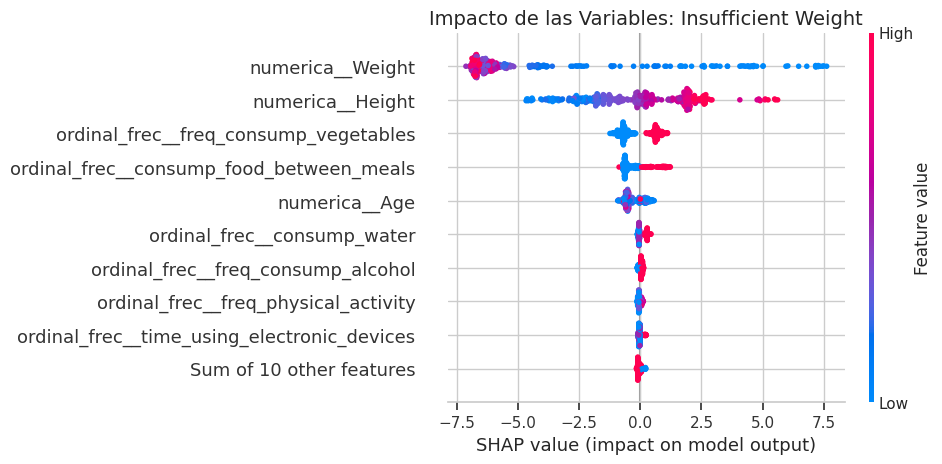

In [54]:
shap.plots.beeswarm(shap_values[:, :, 0], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Insufficient Weight", fontsize=14)

**Insufficient Weight**

1. IMC: Peso y Estatura

El modelo ha capturado la relación peso-estatura:

+ Weight (Peso): Un peso bajo (puntos azules) tiene una fuerte contribución positiva, mientras que el peso alto (rojo) tiene un impacto negativo, es decir, aleja a la persona de ser clasificada en esta categoría.
+ Height (Estatura): Los puntos rojos y magenta (estatura alta) empujan hacia la derecha. El modelo aprendió que tener un peso muy bajo y ser alto es la combinación que lleva a clasificar en "Insufficient Weight".

2. Hábitos alimenticios (Un patrón de consumo frecuente)

El comportamiento dietético muestra un patrón muy interesante:

+ ordinal_frec__freq_consump_vegetables: Los puntos rojos (alto consumo de vegetales) están a la derecha, aumentando la probabilidad de pertenecer a esta clase.
+ ordinal_frec__consump_food_between_meals: Los puntos rojos (mayor frecuencia de consumo de alimentos entre comidas) también empujan sólidamente hacia la derecha. Esto refuerza la idea de que las personas en esta categoría (muchas veces jóvenes con metabolismos acelerados) tienden a hacer múltiples "snacks" o comidas pequeñas a lo largo del día.

3. Edad

Aunque su impacto global es mucho menor que las variables físicas, hay una tendencia visible:

+ Los puntos azules (menor edad) se agrupan ligeramente a la derecha del cero, mientras que los rojos (mayor edad) están a la izquierda. El modelo asocia esta categoría principalmente con personas más jóvenes dentro del conjunto de datos.

4. Variables ausentes: género y antecedentes familiares con sobrepeso

+ El Género : A diferencia de la Obesidad Tipo III (dominada por mujeres) o la Tipo II (dominada por hombres), aquí el género ni siquiera aparece entre las características más importantes. Para el peso insuficiente, el algoritmo no encontró una distinción de género relevante.
+ Historial familiar (binaria_sino__family_history_with_overweight): Tampoco figura en el top. Mientras que el historial familiar es crucial para predecir si alguien entra en sobrepeso u obesidad, para el "Insufficient Weight" el modelo lo considera irrelevante.


+ **Perfil resumen**: Persona con peso muy bajo (independientemente de su género), relativamente alta, jóvenes, con alto consumo de alimentos entre comidas y también un consumo frecuente de vegetales, esto podría deberse a un metabolismo más acelerado cuando se es joven.

#### Normal Weight

Text(0.5, 1.0, 'Impacto de las Variables: Normal Weight')

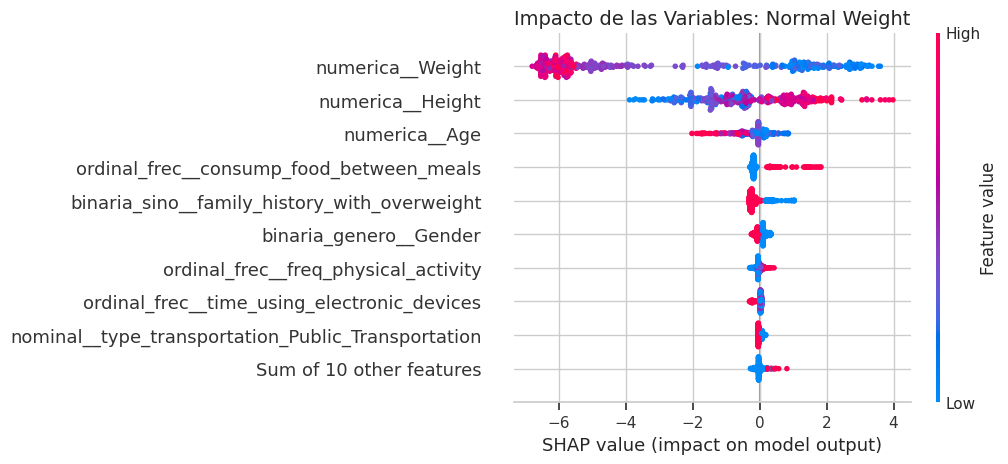

In [55]:
shap.plots.beeswarm(shap_values[:, :, 1], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Normal Weight", fontsize=14)

**Normal Weight**

1. Los motores principales: las variables numéricas, peso y altura, dominan.

+ Weight (Peso): Es la variable más determinante. Los puntos azules (peso bajo) están claramente agrupados a la derecha, indicando que un peso menor aumenta fuertemente la probabilidad de ser clasificado como "Normal Weight". Por el contrario, los puntos rojos (peso alto) se extienden muy hacia la izquierda, penalizando severamente la pertenencia a esta clase.

+ Height (Altura): Su efecto es el inverso. Los puntos rojos (personas más altas) se sitúan a la derecha del cero. Esto significa que a mayor altura, mayor es el impacto positivo para ser clasificado en esta categoría, compensando el peso en la relación del IMC.

2. El impacto del historial y el género (Variables binarias)

+ binaria_sino__family_history_with_overweight: Los puntos azules (0 = No) están a la derecha, mientras que los rojos (1 = Sí) están a la izquierda y fuertemente agrupados. Conclusión: No tener antecedentes familiares de sobrepeso favorece positivamente la clasificación como "Normal Weight". Tenerlos, disminuye la probabilidad.

+ binaria_genero__Gender: Los puntos azules (0 = Hombre) tienden a tener valores SHAP ligeramente positivos, mientras que los rojos (1 = Mujer) tienen valores ligeramente negativos. El modelo ha aprendido que, en este conjunto de datos específico, ser hombre inclina ligeramente la balanza a favor de la clase "Normal Weight" en comparación con ser mujer, aunque el impacto global es menor que el de las variables físicas.

3. Hábitos y estilo de vida (Variables ordinales)

Las variables relacionadas con el comportamiento también muestran patrones claros:

+ ordinal_frec__freq_physical_activity: Como es de esperar, los puntos rojos (mayor frecuencia de actividad física) se ubican del lado derecho. Hacer más ejercicio contribuye a ser clasificado en un peso normal.

+ ordinal_frec__consump_food_between_meals: Aquí se observa que los valores más altos (rojos) de consumo de alimentos entre comidas tienen un impacto positivo (están a la derecha) en la predicción de "Normal Weight". Aunque esto puede sonar contradictorio, existe la posibilidad de que ciertas personas consuman varias comidas pequeñas o refrigerios al día.

+ **Perfil resumen**: peso bajo a moderado, estatura relativamente alta, sin antecedentes familiares de sobrepeso, que realiza actividad física con frecuencia y que suele consumir alimentos entre comidas.

#### Overweight Level I

Text(0.5, 1.0, 'Impacto de las Variables: Overweight Level I')

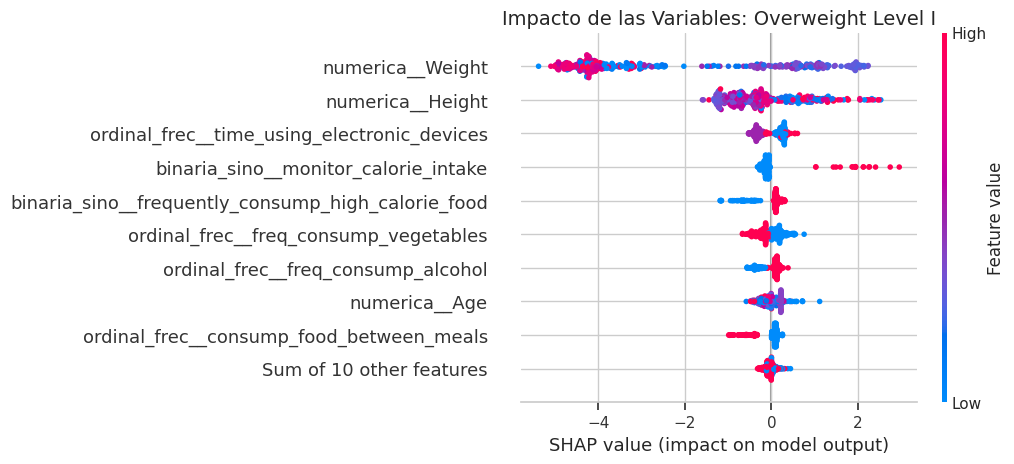

In [56]:
shap.plots.beeswarm(shap_values[:, :, 2], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Overweight Level I", fontsize=14)

**Overweight Level I**

1. Peso (Weight)

Esta es la variable más importante y muestra un patrón de "puntos intermedios".

+ Los puntos rojos (peso muy alto) tienen un valor SHAP fuertemente negativo, lo que significa que un peso muy alto aleja al paciente de esta categoría (probablemente empujándolo hacia niveles de Obesidad I, II o III).

+ Los puntos azules (peso muy bajo) también tienen un valor SHAP negativo, alejándolos hacia las categorías de "Peso Normal" o "Insuficiente".

+ Los puntos morados/fucsias (peso medio) están concentrados en el lado positivo del eje X. Esto indica que el modelo ha identificado un rango de peso específico (ni muy alto ni muy bajo) que es el detonante principal para clasificar a alguien en "Overweight Level I". Esta capacidad de capturar relaciones no lineales es una gran ventaja de los modelos basados en árboles.

2. Estatura (Height)

La estatura tiene un efecto inverso al peso en los extremos.

+ Los puntos rojos (mayor estatura) tienden a tener valores SHAP positivos. Esto tiene sentido lógico: si mantenemos un peso constante, ser más alto reduce el Índice de Masa Corporal (IMC), lo que podría "bajar" a una persona de una categoría de Obesidad hacia "Overweight Level I".

+ Los puntos azules (menor estatura) empujan la predicción hacia la izquierda (negativo), ya que a menor estatura, el mismo peso resulta en un nivel de obesidad mayor.

3. Hábitos alimenticios y consumo

+ Comida Alta en Calorías (binaria_sino__frequently_consump_high_calorie_food): (Sí = 1 = Rojo), vemos que los puntos rojos están agrupados en el lado positivo. Consumir alimentos altos en calorías incrementa la probabilidad de pertenecer a esta categoría de sobrepeso, mientras que no hacerlo (puntos azules) tiene un fuerte impacto negativo, alejando la predicción de esta clase.

+ Consumo de Vegetales (ordinal_frec__freq_consump_vegetables): Un consumo bajo de vegetales (azul) tiene un impacto positivo para clasificar en esta clase, mientras que un consumo alto (rojo) empuja ligeramente la predicción hacia la izquierda.

+ Comida entre comidas (ordinal_frec__consump_food_between_meals): Resulta interesante que un consumo muy frecuente (rojo) empuja la predicción hacia la izquierda de forma muy marcada. Es muy probable que estos valores altos estén fuertemente asociados con las categorías superiores de obesidad, por lo que el modelo los utiliza para descartar el "Nivel I".

4. Uso de Dispositivos (time_using_electronic_devices)

+ El sedentarismo reflejado en el uso de dispositivos muestra que los valores altos (rojo) y medios (fucsia) tienen una ligera tendencia a aportar de forma negativa a la clasificación de esta clase, mientras que los valores bajos (azul) empujan ligeramente hacia la derecha.

Resumen del Perfil

Para que el modelo clasifique una observación como Overweight Level I, busca un perfil muy específico: un individuo con un peso "intermedio" (ni en los extremos de delgadez ni de obesidad severa), que frecuentemente consume comida alta en calorías, tiene un consumo bajo de vegetales y reporta ciertas horas de uso de dispositivos electrónicos. Las variables continuas (peso y altura) son las que dominan absolutamente la magnitud de la decisión, mientras que los hábitos actúan como ajustadores finos del margen.


#### Overweight Level II

Text(0.5, 1.0, 'Impacto de las Variables: Overweight Level II')

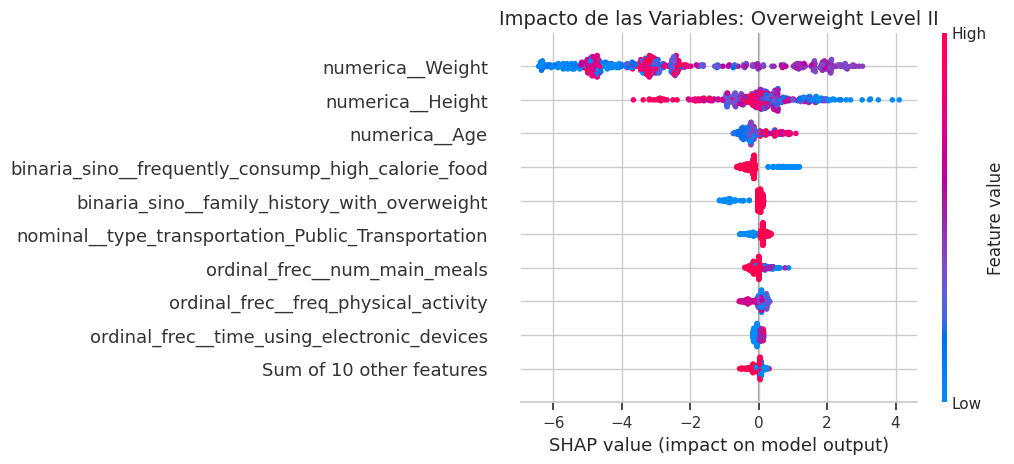

In [57]:
shap.plots.beeswarm(shap_values[:, :, 3], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Overweight Level II", fontsize=14)

**Overweight Level II**
1. Peso

El peso sigue siendo la variable más importante.
+ Los puntos azules (peso muy bajo) están fuertemente a la izquierda. Si el peso es bajo, el modelo rechaza esta clase a favor de "Normal Weight" o "Insufficient Weight".
+ Los puntos rojos intensos (peso muy alto) también están esparcidos hacia la izquierda. El modelo sabe que un peso excesivamente alto pertenece a las categorías de "Obesity (I, II o III)", por lo que penaliza la pertenencia a "Overweight Level II".
+ Observamos puntos morados y magenta del lado derecho del eje X (impacto positivo), lo cual podríamos considerar como peso medio-alto, es decir pesos no muy altos pero tampoco tan bajos, este comportamiento es similar a la anterior categoría "Overweight Level I", ambas pueden catalogarse como categorías intermedias. 

2. Estatura (Height) y Edad

+ La estatura sigue apareciendo como la segunda variable más importante, observamos tanto valores bajos como medios impactando de manera positiva a pertenecer a esta clase. 
+ Los puntos rojos y morados (mayor edad) se agrupan hacia la derecha. El modelo asocia una mayor edad con una mayor probabilidad de pertenecer a "Overweight Level II".

3. Antecedentes familiares y consumo de alimentos calóricos

+ binaria_sino__family_history_with_overweight: Los puntos azules (0 = No) empujan hacia la izquierda (reducen la probabilidad), y los rojos (1 = Sí) empujan hacia la derecha (aumentan la probabilidad).
+ binaria_sino__frequently_consump_high_calorie_food: Los puntos azules (0 = No consume frecuentemente) tienen una cola larga hacia la derecha, aumentando la probabilidad de esta clase. Los puntos rojos (1 = Sí consume) tienden a empujar hacia la izquierda. Esto no significa que comer sano cause sobrepeso. Lo que puede ocurrir es que los que responden "Sí (1)" están siendo empujados con mucha más fuerza hacia otras clases. Por descarte, los que responden "No (0)" pero tienen un peso elevado terminan cayendo en la clase Overweight Level II.

4. Transporte y Actividad física

+ nominal__type_transportation_Public_Transportation: Usar transporte público (rojo) empuja ligeramente a la derecha la predicción de esta clase, en comparación con no usarlo (azul).
+ ordinal_frec__freq_physical_activity: Como es de esperarse, los puntos azules (baja o nula actividad física) se agrupan hacia el lado derecho positivo, sumando puntos para clasificar en sobrepeso.

+ **Perfil resumen**: peso medio-alto, estatura media-baja, sedentarismo combinado con uso frecuente de dispositivos móviles, antedecentes familiares con sobrepeso y pocas comidas principales al día.

#### Obesity Type I

Text(0.5, 1.0, 'Impacto de las Variables: Obesity Type I')

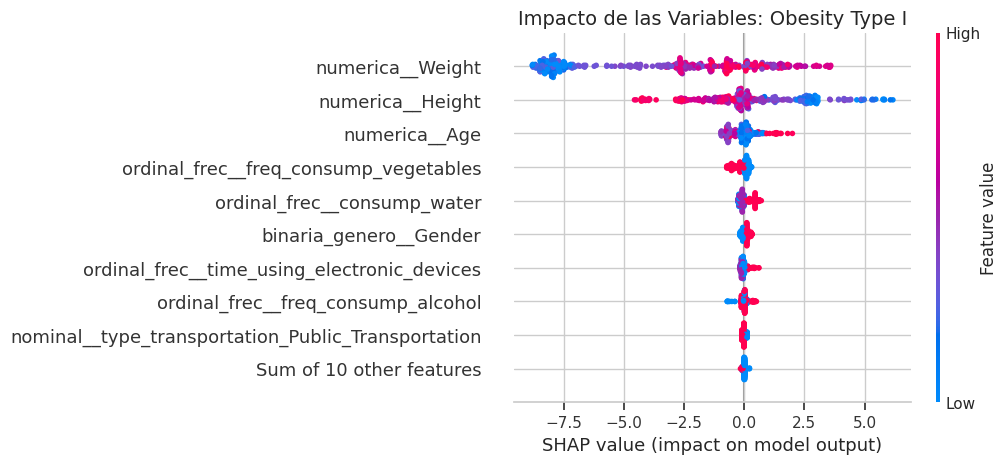

In [58]:
shap.plots.beeswarm(shap_values[:, :, 4], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Obesity Type I", fontsize=14)

**Obesity Type I**

1. Peso

+ Un peso alto, puntos magenta y rojos, tiene un efecto dominante y positivo, se convierte en el motor predictivo principal para clasifcar positivamente en esta categoría. Los puntos azules (peso bajo) están fuertemente relegados a la izquierda.

2. Estatura

+ Los puntos azules (estatura baja), se encuentran esparcidos hacia la derecha. Una persona con baja estatura combinada con un peso elevado (IMC alto) es clasificada con alta probabilidad en "Obesity Type I".

3. Surgen los hábitos alimenticios

En las categorías de peso normal o sobrepeso ligero, la actividad física tenía más protagonismo. Aquí, la dieta toma el control en la parte superior del gráfico:

+ ordinal_frec__freq_consump_vegetables: Los puntos azules (menor consumo de vegetales) están a la derecha, incrementando la probabilidad de pertenecer a esta clase.

+ ordinal_frec__consump_water: Curiosamente, hay una concentración de puntos rojos (alto consumo de agua) a la derecha. En muchos conjuntos de datos de salud nutricional, las personas que ya se encuentran en una categoría de obesidad reportan un mayor consumo de agua porque están intentando activamente compensar o seguir recomendaciones de dieta. El modelo captura este comportamiento como un rasgo de la clase.

4. Género

La dinámica se invirtió por completo respecto a la clase "Normal Weight".

+ Recordando la codificación (Hombre=0, Mujer=1), aquí vemos que los puntos rojos (Mujer) están posicionados a la derecha del cero, mientras que los azules (Hombre) se agrupan ligeramente a la izquierda. Para este conjunto particular de los datos, el modelo detecta que ser mujer incrementa ligeramente la propensión a ser clasificada en esta categoría específica de obesidad frente a ser hombre.

4. Uso de Dispositivos (time_using_electronic_devices)

+ El sedentarismo reflejado en el uso de dispositivos muestra que los valores altos (rojo) tienen una ligera tendencia a aportar de forma positiva a la clasificación de esta clase, mientras que los valores bajos (azul y morados) empujan ligeramente hacia la izquierda.

+ **Perfil resumen**: Peso elevado, estatura media-baja y vemos cómo las variables de ingesta (vegetales, agua) superan a las variables de gasto energético (ejercicio), así como el ser mujer y el uso de dispositivos electrónicos, también son características de esta clase.

#### Obesity Type II

Text(0.5, 1.0, 'Impacto de las Variables: Obesity Type II')

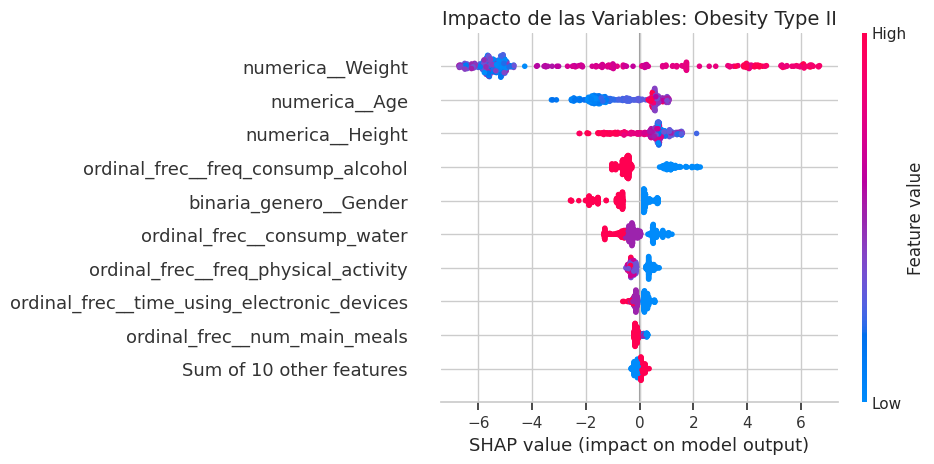

In [59]:
shap.plots.beeswarm(shap_values[:, :, 5], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Obesity Type II", fontsize=14)

**Obesity Type II**
1. El peso sigue dominando, pero la edad toma el control secundario.

+ Weight (Peso): Como era de esperarse, sigue siendo la variable más importante. Los puntos rojos y magenta (pesos muy altos) están fuertemente agrupados a la derecha, siendo el principal motor para clasificar a un paciente en esta categoría. Los pesos bajos (azules) son fuertemente rechazados (empujados hacia la izquierda).

+ Age (Edad): La edad saltó al segundo lugar de importancia. Se observa la fuerte agrupación de puntos azules (personas más jóvenes) extendiéndose hacia la izquierda. El modelo aprendió que ser joven disminuye drásticamente la probabilidad de pertenecer a la Obesidad Tipo II. Por el contrario, las edades medias y altas (puntos morados y rojos) se agrupan a la derecha.

2. La dinámica del Género se invierte nuevamente

+ Gender: Recordando la codificación (Hombre=0/Azul, Mujer=1/Rojo), aquí vemos un giro de 180 grados respecto a la Obesidad Tipo I. En este nivel (Tipo II), los puntos azules (Hombres) se agrupan a la derecha, empujando la predicción a favor de esta clase, mientras que los puntos rojos (Mujeres) son empujados hacia la izquierda. Para este conjunto de datos, el modelo asocia este grado específico de obesidad más fuertemente con los hombres.

3. Hábitos de consumo: Surgen nuevos patrones

El bloque de variables ordinales de frecuencia muestra un perfil conductual muy específico para esta clase:

+ ordinal_frec__freq_consump_alcohol: Los puntos azules (menor frecuencia de consumo de alcohol) están claramente a la derecha. Curiosamente, en este nivel de obesidad, el modelo asocia un menor consumo de alcohol con la pertenencia a la clase.

+ ordinal_frec__consump_water: A diferencia de la Obesidad Tipo I (donde el alto consumo de agua estaba a la derecha), aquí los puntos azules (bajo consumo de agua) son los que empujan la predicción hacia la Obesidad Tipo II de manera positiva.

+ ordinal_frec__freq_physical_activity: Se mantiene la lógica: los puntos azules (nula o baja actividad física) se agrupan a la derecha, aumentando la probabilidad de pertenecer a esta categoría.

4. La consolidación del IMC (numerica__Height)

Aunque bajó al tercer lugar en importancia global, sigue manteniendo esa relación con el peso, la cual podría reflejarse en el IMC. Los puntos azules (menor estatura) están a la derecha. Combinar un peso alto con una estatura baja sigue siendo una regla fundamental (basada en árboles) para asegurar la clasificación en las categorías superiores de obesidad.

+ **Perfil resumen**: Persona con peso muy elevado, de mayor edad, con mayor propensión a ser hombre, de estatura media a baja, que reporta poca actividad física, bajo consumo de agua y bajo consumo de alcohol.


#### Obesity Type III

Text(0.5, 1.0, 'Impacto de las Variables: Obesity Type III')

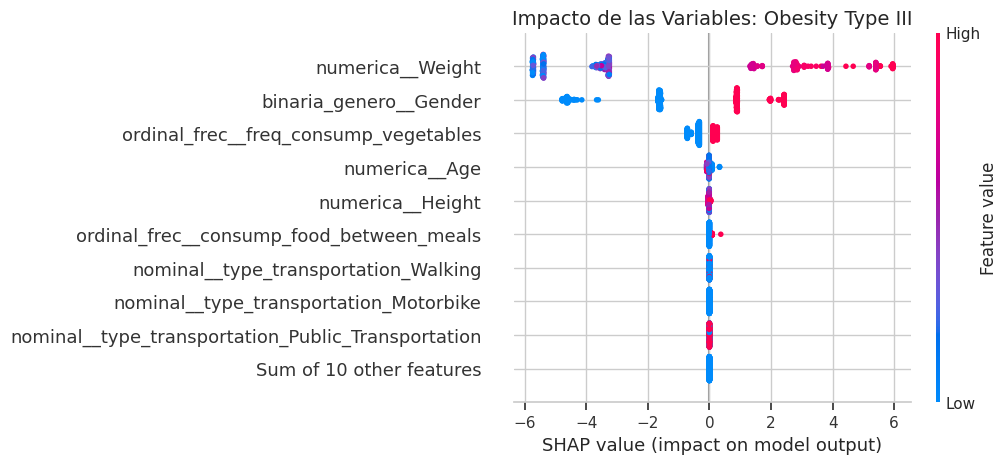

In [60]:
shap.plots.beeswarm(shap_values[:, :, 6], show=False, plot_size=None)
plt.title(f"Impacto de las Variables: Obesity Type III", fontsize=14)

**Obesity Type III**

1. Peso

En las categorías intermedias veíamos gradientes y puntos en tonos magenta o morados. Aquí la polarización es total:

+ Los puntos rojos (pesos extremos) están fuertemente agrupados a la derecha con un impacto altísimo, garantizando casi por sí solos la clasificación en esta categoría.
+ Los puntos azules (pesos bajos y medios) están fuertemente relegados al extremo izquierdo. Para el algoritmo, el peso ha dejado de ser una variable de transición para convertirse en una condición estricta de exclusión o inclusión.

2. Género

Este es el hallazgo más drástico en comparación con Obesity Type II (donde dominaban los hombres).

+ Manteniendo la codificación (Hombre=0/Azul, Mujer=1/Rojo), observamos que los puntos rojos están empujando con muchísima fuerza hacia la derecha, mientras que los azules se agrupan firmemente a la izquierda.
+ El modelo ha detectado que, en este conjunto de datos particular, la Obesity Type III está abrumadoramente asociada a las mujeres. El género saltó a ser la segunda variable más predictiva del modelo, superando a todos los hábitos de consumo.

3. La desaparición de la Estatura y la Edad

+ En casi todas las categorías anteriores, la estatura jugaba un papel muy importante, lo que el modelo podía interpretar internamente como el Índice de Masa Corporal. Aquí, su impacto es casi nulo (los puntos están apilados verticalmente sobre el cero central). Cuando el peso registrado es tan excesivamente alto, la variable por sí sola define la clasificación; la persona entrará en Tipo III sin importar si es muy alta o muy baja.

+ Lo mismo ocurre con la edad, dejó de ser un factor diferenciador fuerte como lo era en el Tipo II.

4. Lo paradójico en el consumo de vegetales

Observamos una agrupación clara de puntos rojos (alto consumo de vegetales) en el lado positivo (derecha), aumentando la probabilidad de pertenencia a esta clase. Vemos un comportamiento similar al igual que sucedió con el consumo de agua en el Tipo I. Tal vez esto se deba a que os pacientes con Obesidad Tipo III frecuentemente se encuentran bajo regímenes médicos estrictos, cirugías bariátricas o dietas fuertemente monitoreadas, por lo que reportan un consumo alto de vegetales. 

+ **Perfil resumen**: El modelo se simplificó enormemente, mujeres con un peso absoluto extremadamente alto, independientemente de su edad o estatura, y que reportan una ingesta alta de vegetales. Las variables sobre el tipo de transporte o las horas frente a dispositivos electrónicos han dejado de importar por completo.

### Conclusiones Generales gráficas SHAP

1. La reconstrucción del IMC (peso y estatura predominan)

El modelo XGBoost logró "deducir" la fórmula del Índice de Masa Corporal (IMC), sin que se le diera la variable explícitamente:

+ Para este conjunto de datos, indiscutiblemente el peso es la variable más importante, esto lo vimos desde los descriptivos, ya que es un claro diferenciador entre las categorías. En los extremos (Insufficient Weight y Obesity Type III), domina por completo la predicción de forma polarizada. En las clases intermedias (Overweight Level II), el modelo logra encontrar los "puntos medios" gracias a su naturaleza no lineal.
+ La estatura también juega un papel importante en casi todas las categorías. Peso bajo o medio y estatura alta, empuja hacia categorías como Insufficient Weight o Normal Weight, mientras que peso alto y estatura baja o media, empujaría a clasificar a la persona en algún tipo de sobrepeso u obesidad. Únicamente en la categoría de "Obesity Type III" la estatura deja de tener relevancia, aquí el peso extremadamente alto es el protagonista.

2. El comportamiento fluctuante del Género

+ En Normal Weight, se inclinaba ligeramente hacia los hombres.
+ En Obesity Type I, se inclinó ligeramente hacia las mujeres.
+ En Obesity Type II, se asoció fuertemente con los hombres.
+ En Obesity Type III, se volvió una regla casi exclusiva para las mujeres.

Esto demuestra que el algoritmo encontró interacciones profundas (probablemente ligadas a características biológicas y demográficas específicas de este conjunto de datos) 


3. La Paradoja de los Hábitos (Causalidad Inversa)

El modelo detectó patrones de consumo que a primera vista parecen contraintuitivos, pero que pueden ser un reflejo de la realidad médica observacional:

+ Un alto consumo de agua o vegetales apareció fuertemente ligado a categorías como Obesity Type I y Obesity Type III. Esto no indica que tomar agua o comer verduras cause obesidad, sino que refleja un sesgo de tratamiento o compensación: las personas en niveles altos de obesidad suelen estar sometidas a dietas, tratamientos médicos o intentos activos de mejorar su salud, reportando consumos altos de estos alimentos "sanos".
+ Por otro lado, comer frecuentemente entre comidas se asoció más con Normal Weight e Insufficient Weight, desmintiendo la idea general de que "picoteos" simples causan aumento de peso sin contexto de las porciones o metabolismo.

4. La Edad y el Historial Familiar

+ Ser más joven empuja hacia el peso normal o insuficiente, mientras que la edad media y avanzada son cruciales para clasificar en sobrepeso u obesidad tipo II. Sin embargo, en los extremos absolutos (Obesity Type III), la edad deja de importar.
+ El Historial Familiar es la barrera de entrada al sobrepeso. No tenerlo es el principal escudo protector para mantenerse en Normal Weight, pero una vez que el paciente cruza hacia la obesidad, las variables físicas y los hábitos toman el relevo.

5. Actividad física y uso de dispositivos electrónicos

El sedentarismo se refleja ya sea en la poca o nula actividad física y/o en el tiempo que se pasa frente a dispositivos electrónicos. Aunque estas variables no aparecen en el top, sí tienen un comportamiento claro en Overweight Level II, Obesity Type I y II.

La ayuda de un especialista en este campo nos permitiría confirmar o rechazar y dar una mejor interpretación de los resultados.

# Preguntas complementarias

La obesidad es una enfermedad multifactorial, algunas otras preguntas y variables que aportarían información relevante, para entender no solo qué hace la persona, sino el contexto biológico y social que la empuja a mantener un balance energético específico, podrían ser:

1. Factores Biológicos y Genéticos

1.1 ¿Cuál fue la calidad de la alimentación durante la infancia (lactancia materna) y cómo fue el crecimiento durante esa etapa?

2. Factores Psicológicos Individuales

2.1 ¿Qué tan estresado se siente habitualmente?

2.2 ¿Cuál es su nivel de confianza y sentido de propósito personal?

2.3 ¿Qué tan capaz se siente de evaluar la calidad nutricional y el origen de lo que consume? (¿Le las etiquetas de los productos que consume?)

3. Entorno y Actividad Ambiental

3.1 ¿Qué tan fácil y seguro es caminar en su vecindario o lugar de residencia?

3.2 ¿Con qué frecuencia está expuesto a anuncios de alimentos procesados o de alta densidad calórica?

3.3 ¿Existen instalaciones seguras para usar bicicleta o caminar como medio de transporte?

4. Influencias Sociales y Económicas

4.1 ¿Qué tanto influyen las elecciones de comida de sus amigos o círculos cercanos en sus propios hábitos?

4.2 ¿Tiene los recursos económicos suficientes para acceder a alimentos frescos en lugar de opciones procesadas más económicas?

4.3 ¿Siente que su jornada laboral o estilo de vida le impide preparar comidas saludables o realizar actividad física?

5. Estigma y Salud Mental

5.1 ¿Ha sufrido trato injusto o comentarios negativos debido a su cuerpo?

5.2 ¿Qué acciones de autocuidado realiza que le generen bienestar no solo físico, sino también social y ambiental?

### Referencias

* [1]   Vandenbroeck, P., Goossens, J., & Clemens, M. (2007). *Tackling obesities: Future choices – Obesity system atlas*. Government Office for Science. [https://assets.publishing.service.gov.uk/media/5a7b8811ed915d4147620fb2/07-1177-obesity-system-atlas.pdf](https://assets.publishing.service.gov.uk/media/5a7b8811ed915d4147620fb2/07-1177-obesity-system-atlas.pdf)
* [2]   Palechor, F. M., & de la Hoz Manotas, A. (2019). *Estimation of Obesity Levels Based On Eating Habits and Physical Condition* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5H31Z](https://doi.org/10.24432/C5H31Z)
* [3]   De-La-Hoz-Correa, E., et al. (2019). Obesity Level Estimation Software based on Decision Trees. *Journal of Computer Science*, *15*(1), 67-77. [https://doi.org/10.3844/jcssp.2019.67.77](https://doi.org/10.3844/jcssp.2019.67.77)
* [4]   Organización Mundial de la Salud. (2024). *Obesidad y sobrepeso*. [https://www.who.int/es/news-room/fact-sheets/detail/obesity-and-overweight](https://www.who.int/es/news-room/fact-sheets/detail/obesity-and-overweight)